Exhaustive kNN sweep for all datasets

🗄️ Step 1: Configuring 12 Datasets...
⚙️ Step 2: Loading and cleaning individual datasets...


Loading Parquets: 100%|██████████| 12/12 [00:26<00:00,  2.18s/it]



🚀 Step 3: Running 66 pairwise kNN comparisons...


Pairwise Align & kNN: 100%|██████████| 66/66 [03:57<00:00,  3.60s/it]



🎨 Step 4: Generating All-by-All Comparison Heatmaps...


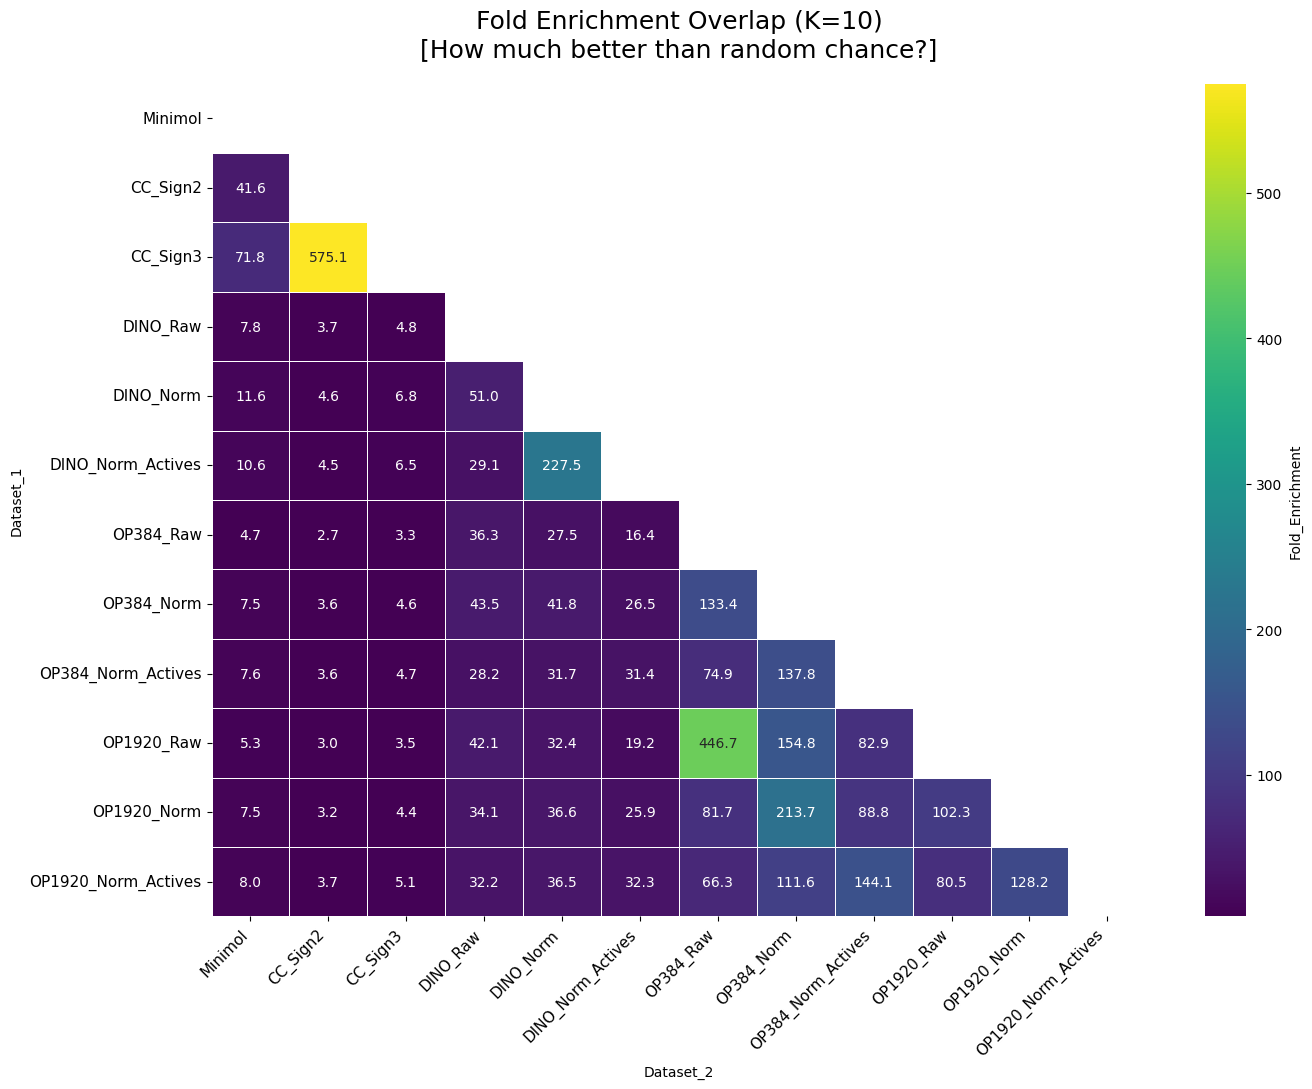

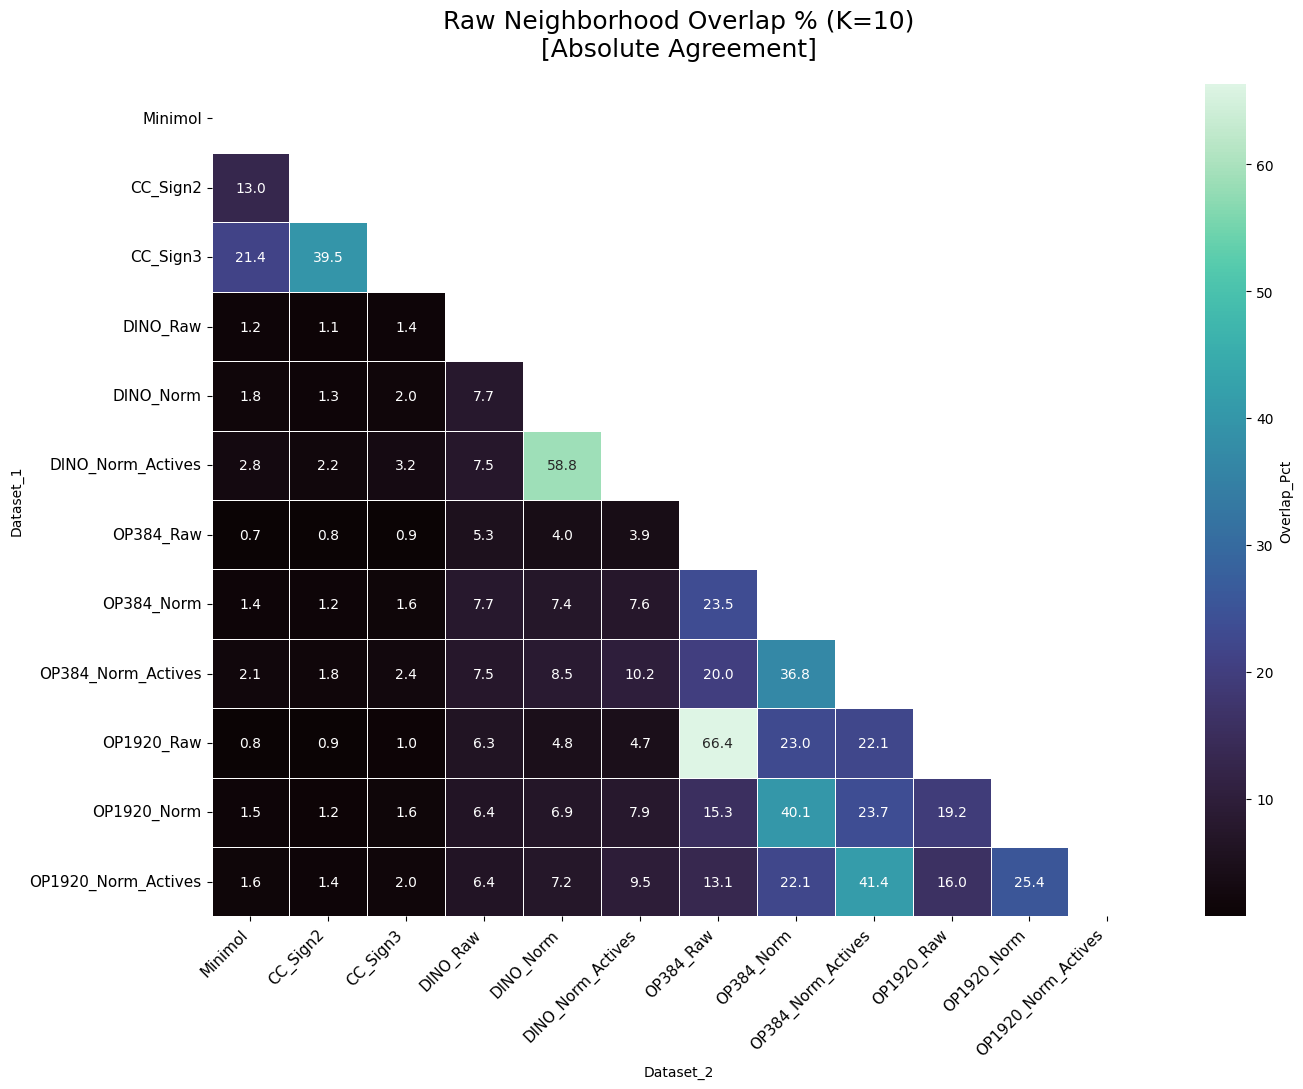


🏆 TOP 10 STRONGEST CROSS-DATASET CONNECTIONS (Ranked by Fold Enrichment at K=10):


,Dataset_1,Dataset_2,Aligned_Molecules,Overlap_Pct,Fold_Enrichment
57,CC_Sign2,CC_Sign3,21465,39.48,575.09
262,OP384_Raw,OP1920_Raw,9946,66.35,446.67
192,DINO_Norm,DINO_Norm_Actives,6077,58.76,227.52
287,OP384_Norm,OP1920_Norm,9946,40.13,213.68
282,OP384_Norm,OP1920_Raw,9946,22.99,154.76
327,OP384_Norm_Actives,OP1920_Norm_Actives,5931,41.45,144.14
292,OP384_Norm,OP384_Norm_Actives,5941,36.80,137.79
257,OP384_Raw,OP384_Norm,9946,23.52,133.42
322,OP1920_Norm,OP1920_Norm_Actives,8544,25.42,128.20
297,OP384_Norm,OP1920_Norm_Actives,8544,22.14,111.63


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import itertools
import time
import gc

# =====================================================================
# 1. DATASET CONFIGURATION & PATHS
# =====================================================================
print("🗄️ Step 1: Configuring 12 Datasets...")

# Clean, short names for the heatmap visualizations!
datasets_config = {
    'Minimol': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__Kim_et_al_subset_final.parquet',
    'CC_Sign2': 'gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/parquets/JUMPCP_CC_Sign2_Global_Signatures.parquet',
    'CC_Sign3': 'gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/parquets/JUMPCP_Sign3_CC_final.parquet',
    'DINO_Raw': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_nonorm_final.parquet',
    'DINO_Norm': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_normed_final.parquet',
    'DINO_Norm_Actives': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/Bayer_DINO_embeddings_normed_final-actives_only.parquet',
    'OP384_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384.parquet',
    'OP384_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized.parquet',
    'OP1920_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920.parquet',
    'OP1920_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized.parquet',
    'OP384_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized-ACTIVE.parquet',
    'OP1920_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized-ACTIVE.parquet'
}

# =====================================================================
# 2. LOAD & STANDARDIZE ALL DATASETS INTO RAM
# =====================================================================
loaded_dfs = {}

def safely_set_inchikey_index(df, name):
    if df.index.name and 'inchikey' in str(df.index.name).lower():
        df.index.name = 'InChIKey'
        return df
    if df.index.name is None and isinstance(df.index[0], str) and len(str(df.index[0])) >= 25:
        df.index.name = 'InChIKey'
        return df
    inchikey_col = next((c for c in df.columns if 'inchikey' in c.lower()), None)
    if inchikey_col:
        df = df.set_index(inchikey_col)
        df.index.name = 'InChIKey'
        return df
    raise KeyError(f"Could not find an InChIKey column in {name}")

print("⚙️ Step 2: Loading and cleaning individual datasets...")
for name, path in tqdm(datasets_config.items(), desc="Loading Parquets"):
    try:
        df = pd.read_parquet(path)
        df = safely_set_inchikey_index(df, name)
        df = df[~df.index.duplicated(keep='first')]

        # Isolate pure numeric features to keep RAM usage incredibly low
        df_embs = df.select_dtypes(include=[np.number]).astype(np.float32)
        loaded_dfs[name] = df_embs
    except Exception as e:
        print(f"   ❌ Failed to load {name}: {e}")

# =====================================================================
# 3. ALL-BY-ALL PAIRWISE KNN SWEEP
# =====================================================================
K_LIST = [1, 5, 10, 20, 50]
MAX_K = max(K_LIST)

dataset_names = list(loaded_dfs.keys())
combinations = list(itertools.combinations(dataset_names, 2))

print(f"\n🚀 Step 3: Running {len(combinations)} pairwise kNN comparisons...")

all_results = []

for name_A, name_B in tqdm(combinations, desc="Pairwise Align & kNN"):
    df_A = loaded_dfs[name_A]
    df_B = loaded_dfs[name_B]

    # 1. Align the pair dynamically
    df_A_aligned, df_B_aligned = df_A.align(df_B, join='inner', axis=0)
    df_A_aligned.fillna(0.0, inplace=True)
    df_B_aligned.fillna(0.0, inplace=True)

    num_molecules = len(df_A_aligned)
    if num_molecules <= MAX_K:
        continue # Skip if an alignment fails or yields too few molecules

    X = df_A_aligned.values
    Y = df_B_aligned.values
    total_possible_pairs = (num_molecules * (num_molecules - 1)) / 2

    # 2. Fit KNN
    knn_X = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(X)
    knn_Y = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(Y)

    _, indices_X_full = knn_X.kneighbors(X)
    _, indices_Y_full = knn_Y.kneighbors(Y)

    # 3. Evaluate each K
    for k in K_LIST:
        current_rows = np.repeat(np.arange(num_molecules), k)

        # Deduplicated edges for Space X
        cols_X = indices_X_full[:, 1:k+1].flatten()
        min_X, max_X = np.minimum(current_rows, cols_X), np.maximum(current_rows, cols_X)
        unique_edges_X = { (u, v) for u, v in zip(min_X, max_X) if u != v }

        # Deduplicated edges for Space Y
        cols_Y = indices_Y_full[:, 1:k+1].flatten()
        min_Y, max_Y = np.minimum(current_rows, cols_Y), np.maximum(current_rows, cols_Y)
        unique_edges_Y = { (u, v) for u, v in zip(min_Y, max_Y) if u != v }

        # Intersection
        num_shared = len(unique_edges_X.intersection(unique_edges_Y))
        overlap_pct = num_shared / len(unique_edges_X) if len(unique_edges_X) > 0 else 0
        random_expected = len(unique_edges_Y) / total_possible_pairs
        fold_enrichment = overlap_pct / random_expected if random_expected > 0 else 0

        all_results.append({
            'Dataset_1': name_A,
            'Dataset_2': name_B,
            'Aligned_Molecules': num_molecules,
            'k': k,
            'Overlap_Pct': overlap_pct * 100,
            'Fold_Enrichment': fold_enrichment
        })

    # Free memory
    del df_A_aligned, df_B_aligned, X, Y, knn_X, knn_Y, indices_X_full, indices_Y_full
    gc.collect()

df_results = pd.DataFrame(all_results)

# =====================================================================
# 4. VISUALIZE THE ALL-BY-ALL HEATMAPS
# =====================================================================
print("\n🎨 Step 4: Generating All-by-All Comparison Heatmaps...")

def plot_heatmap(df, metric, title, k_target=10):
    """Helper function to build a symmetric 12x12 heatmap from the pairwise results"""
    # Isolate the specific K
    df_k = df[df['k'] == k_target].copy()

    # We need to mirror the dataset to make a full square matrix
    df_mirror = df_k.rename(columns={'Dataset_1': 'Dataset_2', 'Dataset_2': 'Dataset_1'})
    df_full = pd.concat([df_k, df_mirror])

    # Add self-comparisons as perfect scores on the diagonal for aesthetics
    self_comps = pd.DataFrame({
        'Dataset_1': dataset_names,
        'Dataset_2': dataset_names,
        metric: [df_full[metric].max()] * len(dataset_names) # Max out the diagonal
    })
    df_full = pd.concat([df_full, self_comps])

    # Pivot into a 12x12 grid
    pivot_table = df_full.pivot(index='Dataset_1', columns='Dataset_2', values=metric)

    # Order the matrix carefully (Structure -> Bio -> Morph)
    ordered_cols = ['Minimol', 'CC_Sign2', 'CC_Sign3',
                    'DINO_Raw', 'DINO_Norm', 'DINO_Norm_Actives',
                    'OP384_Raw', 'OP384_Norm', 'OP384_Norm_Actives',
                    'OP1920_Raw', 'OP1920_Norm', 'OP1920_Norm_Actives']

    # Filter to only datasets that actually successfully joined
    ordered_cols = [c for c in ordered_cols if c in pivot_table.columns]
    pivot_table = pivot_table.reindex(index=ordered_cols, columns=ordered_cols)

    plt.figure(figsize=(14, 11))

    # Mask the upper triangle for a cleaner look (optional, but standard for correlation matrices)
    mask = np.triu(np.ones_like(pivot_table, dtype=bool))

    sns.heatmap(pivot_table, mask=mask, cmap='viridis' if 'Enrichment' in metric else 'mako',
                annot=True, fmt=".1f", linewidths=.5, cbar_kws={'label': metric})

    plt.title(title, fontsize=18, pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()

# Generate Heatmap 1: Fold Enrichment at K=10 (Signal-to-Noise Ratio)
plot_heatmap(df_results, 'Fold_Enrichment', 'Fold Enrichment Overlap (K=10)\n[How much better than random chance?]')

# Generate Heatmap 2: Raw Overlap % at K=10 (Absolute Agreement)
plot_heatmap(df_results, 'Overlap_Pct', 'Raw Neighborhood Overlap % (K=10)\n[Absolute Agreement]')

# =====================================================================
# 5. SUMMARY OF TOP PAIRS
# =====================================================================
print("\n🏆 TOP 10 STRONGEST CROSS-DATASET CONNECTIONS (Ranked by Fold Enrichment at K=10):")
print("=" * 100)

top_10 = df_results[df_results['k'] == 10].sort_values(by='Fold_Enrichment', ascending=False).head(10)
display(top_10[['Dataset_1', 'Dataset_2', 'Aligned_Molecules', 'Overlap_Pct', 'Fold_Enrichment']].round(2))

# Optional: Save the master dataframe to GCS for later plotting
# df_results.to_csv('gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/All_By_All_KNN_Results.csv', index=False)

Focus on cross-modality comparisons

🗄️ Step 1: Configuring 12 Datasets...
⚙️ Step 2: Loading and cleaning individual datasets...


Loading Parquets: 100%|██████████| 12/12 [00:21<00:00,  1.80s/it]



🚀 Step 3: Running deduplicated k-Sweep across 66 dataset pairs...


Pairwise Align & kNN: 100%|██████████| 66/66 [14:34<00:00, 13.25s/it]



🎨 Step 4: Generating Master k-Sweep Visualizations...


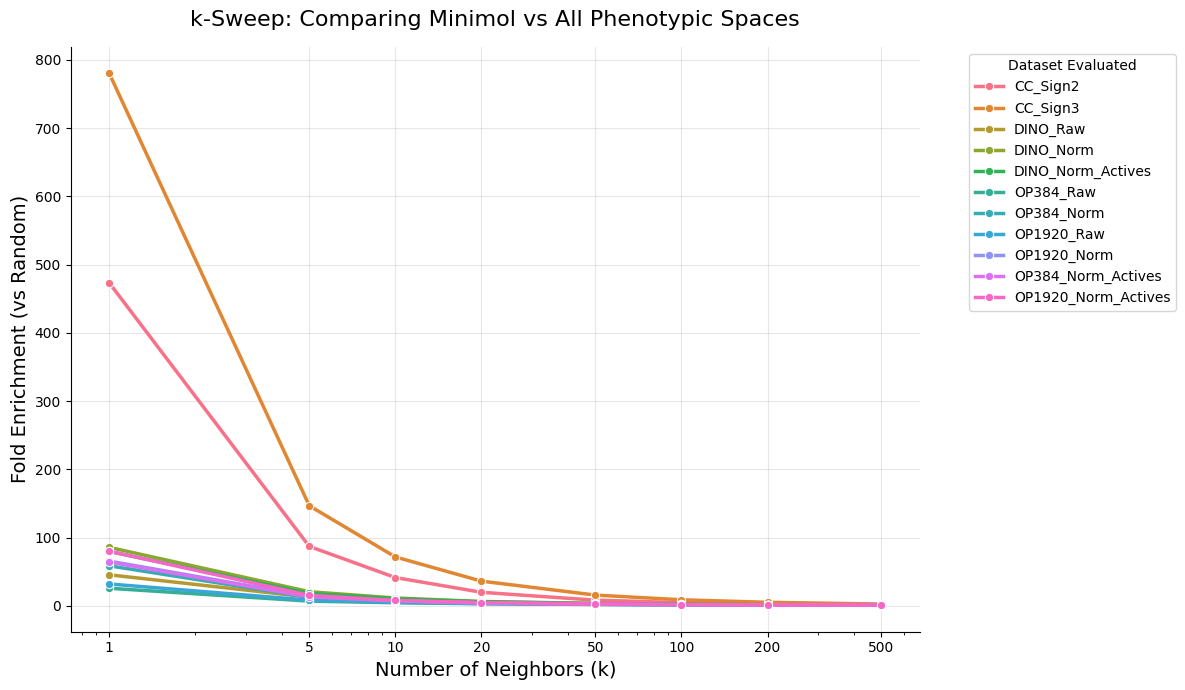

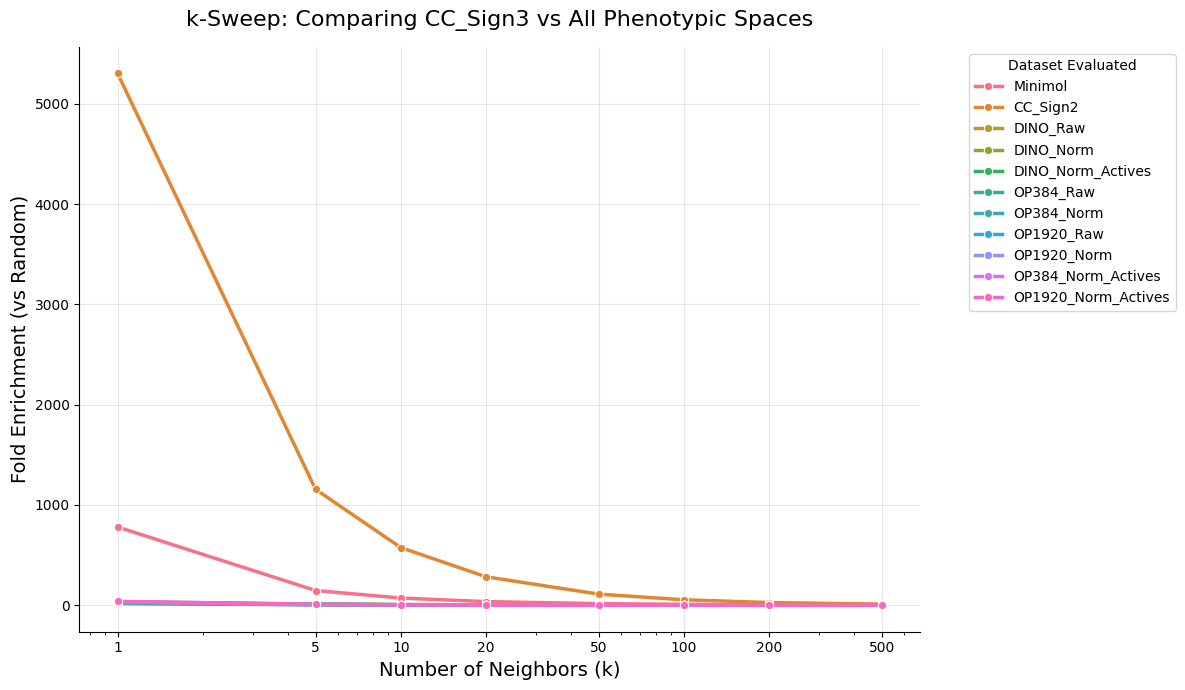

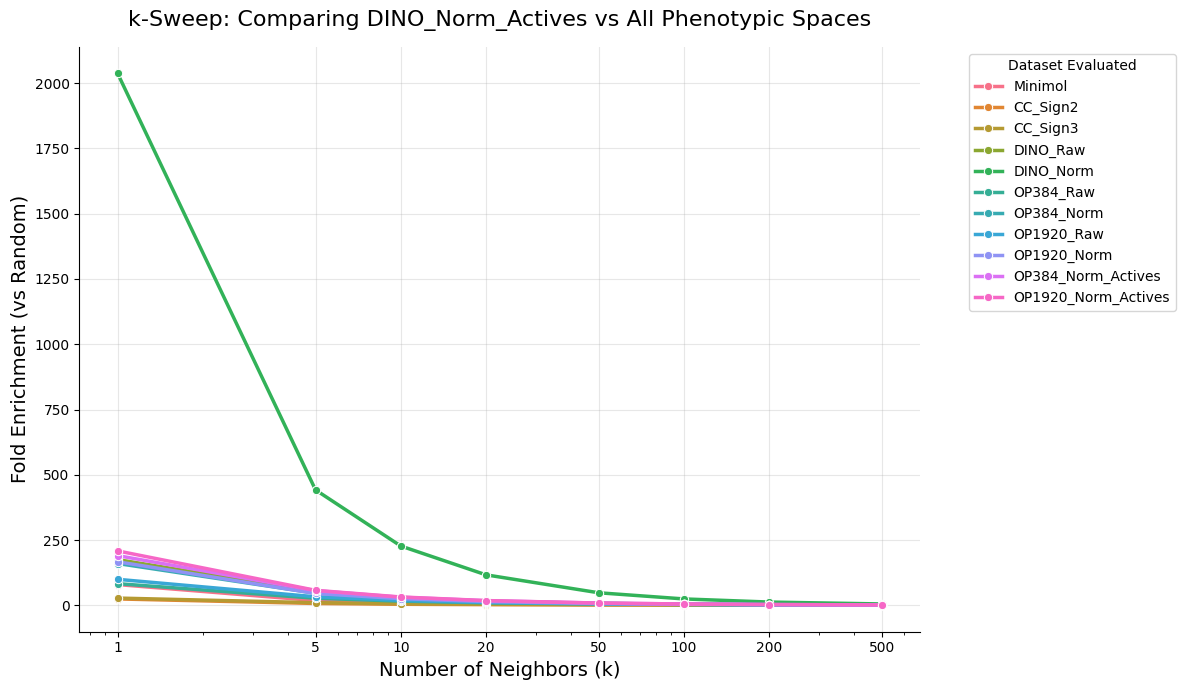

✅ Analysis Complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import itertools
import time
import gc

# =====================================================================
# 1. DATASET CONFIGURATION & PATHS
# =====================================================================
print("🗄️ Step 1: Configuring 12 Datasets...")

# Clean, short names for the visual legends
datasets_config = {
    'Minimol': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__Kim_et_al_subset_final.parquet',
    'CC_Sign2': 'gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/parquets/JUMPCP_CC_Sign2_Global_Signatures.parquet',
    'CC_Sign3': 'gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/parquets/JUMPCP_Sign3_CC_final.parquet',
    'DINO_Raw': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_nonorm_final.parquet',
    'DINO_Norm': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_normed_final.parquet',
    'DINO_Norm_Actives': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/Bayer_DINO_embeddings_normed_final-actives_only.parquet',
    'OP384_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384.parquet',
    'OP384_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized.parquet',
    'OP1920_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920.parquet',
    'OP1920_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized.parquet',
    'OP384_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized-ACTIVE.parquet',
    'OP1920_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized-ACTIVE.parquet'
}

# =====================================================================
# 2. LOAD & STANDARDIZE ALL DATASETS INTO RAM
# =====================================================================
loaded_dfs = {}

def safely_set_inchikey_index(df, name):
    if df.index.name and 'inchikey' in str(df.index.name).lower():
        df.index.name = 'InChIKey'
        return df
    if df.index.name is None and isinstance(df.index[0], str) and len(str(df.index[0])) >= 25:
        df.index.name = 'InChIKey'
        return df
    inchikey_col = next((c for c in df.columns if 'inchikey' in c.lower()), None)
    if inchikey_col:
        df = df.set_index(inchikey_col)
        df.index.name = 'InChIKey'
        return df
    raise KeyError(f"Could not find an InChIKey column in {name}")

print("⚙️ Step 2: Loading and cleaning individual datasets...")
for name, path in tqdm(datasets_config.items(), desc="Loading Parquets"):
    try:
        df = pd.read_parquet(path)
        df = safely_set_inchikey_index(df, name)
        df = df[~df.index.duplicated(keep='first')]

        # Isolate pure numeric features to keep RAM usage incredibly low
        df_embs = df.select_dtypes(include=[np.number]).astype(np.float32)
        loaded_dfs[name] = df_embs
    except Exception as e:
        print(f"   ❌ Failed to load {name}: {e}")

# =====================================================================
# 3. ALL-BY-ALL PAIRWISE KNN SWEEP
# =====================================================================
K_LIST = [1, 5, 10, 20, 50, 100, 200, 500]

dataset_names = list(loaded_dfs.keys())
combinations = list(itertools.combinations(dataset_names, 2))

print(f"\n🚀 Step 3: Running deduplicated k-Sweep across {len(combinations)} dataset pairs...")

all_results = []

for name_A, name_B in tqdm(combinations, desc="Pairwise Align & kNN"):
    df_A = loaded_dfs[name_A]
    df_B = loaded_dfs[name_B]

    # 1. Align the pair dynamically
    df_A_aligned, df_B_aligned = df_A.align(df_B, join='inner', axis=0)
    df_A_aligned.fillna(0.0, inplace=True)
    df_B_aligned.fillna(0.0, inplace=True)

    num_molecules = len(df_A_aligned)

    # Ensure we don't try to sweep K larger than the available molecules
    valid_k_list = [k for k in K_LIST if k < num_molecules]
    if not valid_k_list:
        continue # Skip if alignment fails or yields too few molecules

    MAX_K = max(valid_k_list)
    X = df_A_aligned.values
    Y = df_B_aligned.values
    total_possible_pairs = (num_molecules * (num_molecules - 1)) / 2

    # 2. Fit KNN once for MAX_K
    knn_X = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(X)
    knn_Y = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(Y)

    _, indices_X_full = knn_X.kneighbors(X)
    _, indices_Y_full = knn_Y.kneighbors(Y)

    # 3. Evaluate each K
    base_rows = np.repeat(np.arange(num_molecules), MAX_K)

    for k in valid_k_list:
        current_rows = np.repeat(np.arange(num_molecules), k)

        # Deduplicated edges for Space X
        cols_X = indices_X_full[:, 1:k+1].flatten()
        min_X, max_X = np.minimum(current_rows, cols_X), np.maximum(current_rows, cols_X)
        unique_edges_X = { (u, v) for u, v in zip(min_X, max_X) if u != v }

        # Deduplicated edges for Space Y
        cols_Y = indices_Y_full[:, 1:k+1].flatten()
        min_Y, max_Y = np.minimum(current_rows, cols_Y), np.maximum(current_rows, cols_Y)
        unique_edges_Y = { (u, v) for u, v in zip(min_Y, max_Y) if u != v }

        # Intersection
        num_shared = len(unique_edges_X.intersection(unique_edges_Y))
        overlap_pct = num_shared / len(unique_edges_X) if len(unique_edges_X) > 0 else 0
        random_expected = len(unique_edges_Y) / total_possible_pairs
        fold_enrichment = overlap_pct / random_expected if random_expected > 0 else 0

        all_results.append({
            'Dataset_1': name_A,
            'Dataset_2': name_B,
            'Aligned_Molecules': num_molecules,
            'k': k,
            'Overlap_Pct': overlap_pct * 100,
            'Fold_Enrichment': fold_enrichment
        })

    # Brutal RAM cleanup for the next combination
    del df_A_aligned, df_B_aligned, X, Y, knn_X, knn_Y, indices_X_full, indices_Y_full
    gc.collect()

df_results = pd.DataFrame(all_results)

# =====================================================================
# 4. VISUALIZE THE K-SWEEPS (ANCHOR-BASED)
# =====================================================================
print("\n🎨 Step 4: Generating Master k-Sweep Visualizations...")

# Clean aesthetic color map for 11 comparison lines
colors = sns.color_palette("husl", 11)

def plot_anchor_sweep(df, anchor_name, metric='Fold_Enrichment', metric_label='Fold Enrichment'):
    """Extracts all comparisons involving the anchor and plots their k-sweeps"""
    # Find all rows where Dataset 1 or Dataset 2 is the anchor
    df_anchor = df[(df['Dataset_1'] == anchor_name) | (df['Dataset_2'] == anchor_name)].copy()

    if df_anchor.empty:
        print(f"⚠️ No successful alignments found for {anchor_name}.")
        return

    # Standardize the 'Comparison' label so the anchor is removed from the name
    df_anchor['Comparison'] = np.where(
        df_anchor['Dataset_1'] == anchor_name,
        df_anchor['Dataset_2'],
        df_anchor['Dataset_1']
    )

    plt.figure(figsize=(12, 7))
    sns.lineplot(
        data=df_anchor,
        x='k',
        y=metric,
        hue='Comparison',
        marker='o',
        linewidth=2.5,
        palette=colors
    )

    plt.xscale('log')
    plt.xticks(K_LIST)
    plt.gca().get_xaxis().set_major_formatter(plt.ScalarFormatter())

    plt.title(f'k-Sweep: Comparing {anchor_name} vs All Phenotypic Spaces', fontsize=16, pad=15)
    plt.xlabel('Number of Neighbors (k)', fontsize=14)
    plt.ylabel(metric_label, fontsize=14)

    # Move legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Dataset Evaluated")
    plt.grid(True, alpha=0.3)
    sns.despine()
    plt.tight_layout()
    plt.show()

# --- 1. MINIMOL AS THE ANCHOR (Chemistry vs Biology) ---
plot_anchor_sweep(df_results, anchor_name='Minimol', metric='Fold_Enrichment', metric_label='Fold Enrichment (vs Random)')

# --- 2. CHEMICAL CHECKER SIGN3 AS THE ANCHOR (Target Bio vs Morphological Bio) ---
plot_anchor_sweep(df_results, anchor_name='CC_Sign3', metric='Fold_Enrichment', metric_label='Fold Enrichment (vs Random)')

# --- 3. DINO NORM ACTIVES AS THE ANCHOR (Morphology vs Everything Else) ---
plot_anchor_sweep(df_results, anchor_name='DINO_Norm_Actives', metric='Fold_Enrichment', metric_label='Fold Enrichment (vs Random)')

print("✅ Analysis Complete!")

# Optional: Save the master dataframe to GCS for later plotting
# df_results.to_csv('gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/All_By_All_KNN_Sweep_Results.csv', index=False)

🗄️ Step 1: Configuring Target Datasets...
⚙️ Step 2: Loading and cleaning datasets...


Loading Parquets: 100%|██████████| 4/4 [00:05<00:00,  1.28s/it]



🚀 Step 3: Running k-Sweep across 6 dataset pairs...


Pairwise Align & kNN: 100%|██████████| 6/6 [01:04<00:00, 10.76s/it]
/tmp/ipykernel_135/825885356.py:162: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.lineplot(data=df_anchor, x='k', y='Overlap_Pct', hue='Comparison',
/tmp/ipykernel_135/825885356.py:174: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.lineplot(data=df_anchor, x='k', y='Fold_Enrichment', hue='Comparison',



🎨 Step 4: Generating K-Sweep Visualizations...


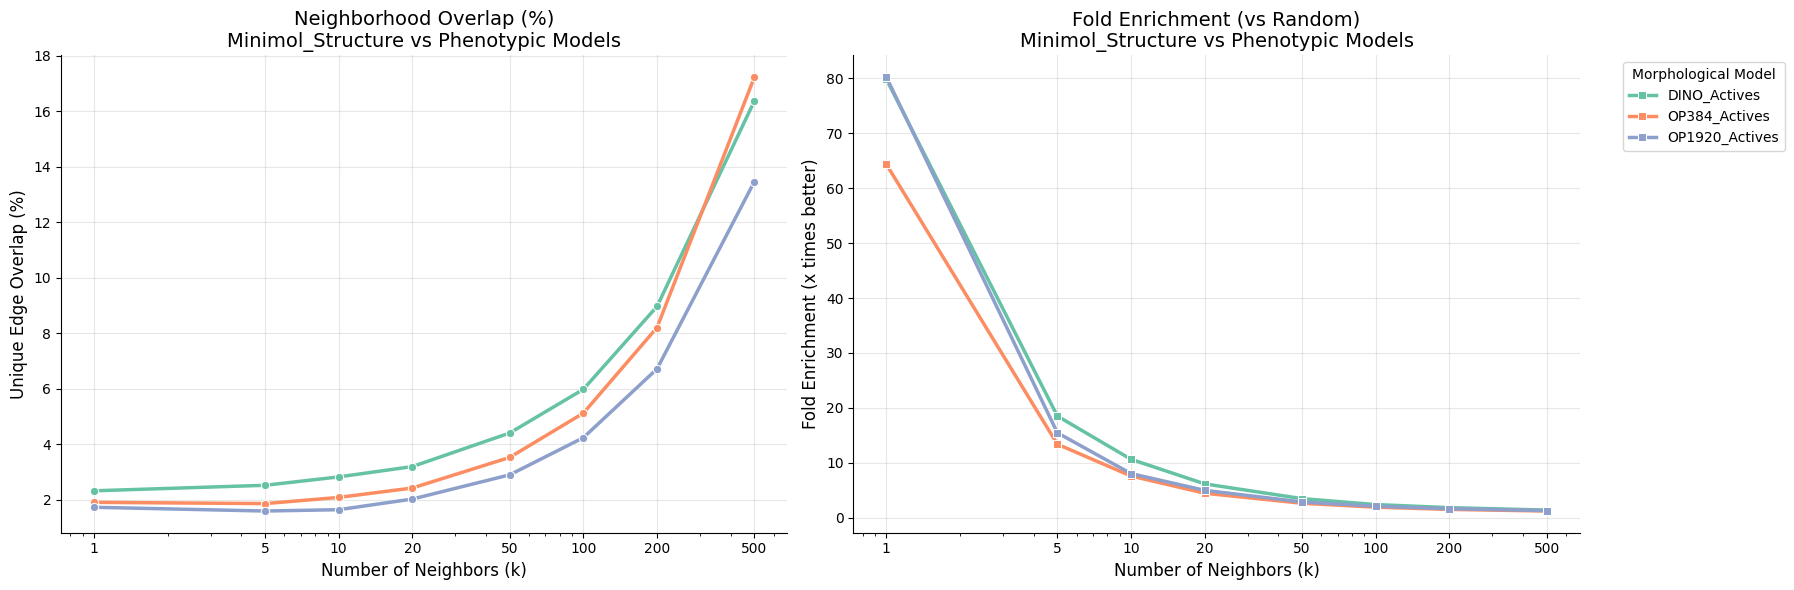


🏆 TOP PHENOTYPIC MODELS AT K=10 (The 'Pharmacological Family' Zone):


,Dataset_1,Dataset_2,Aligned_Molecules,Overlap_Pct,Random_Overlap,Fold_Enrichment,Likelihood_GT_Chance,P_Value
0,Minimol_Structure,DINO_Actives,5890,2.83,0.2662%,10.6,>99.99%,0.00e+00
1,Minimol_Structure,OP1920_Actives,8257,1.65,0.2054%,8.0,>99.99%,0.00e+00
2,Minimol_Structure,OP384_Actives,5756,2.09,0.2755%,7.6,>99.99%,0.00e+00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from scipy.stats import hypergeom
from tqdm import tqdm
import itertools
import time
import gc

# =====================================================================
# 1. DATASET CONFIGURATION
# =====================================================================
print("🗄️ Step 1: Configuring Target Datasets...")

datasets_config = {
    'Minimol_Structure': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__Kim_et_al_subset_final.parquet',
    'DINO_Actives': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/Bayer_DINO_embeddings_normed_final-actives_only.parquet',
    'OP384_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized-ACTIVE.parquet',
    'OP1920_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized-ACTIVE.parquet'
}

# =====================================================================
# 2. LOAD & STANDARDIZE ALL DATASETS INTO RAM
# =====================================================================
loaded_dfs = {}

def safely_set_inchikey_index(df, name):
    if df.index.name and 'inchikey' in str(df.index.name).lower():
        df.index.name = 'InChIKey'
        return df
    if df.index.name is None and isinstance(df.index[0], str) and len(str(df.index[0])) >= 25:
        df.index.name = 'InChIKey'
        return df
    inchikey_col = next((c for c in df.columns if 'inchikey' in c.lower()), None)
    if inchikey_col:
        df = df.set_index(inchikey_col)
        df.index.name = 'InChIKey'
        return df
    raise KeyError(f"Could not find an InChIKey column in {name}")

print("⚙️ Step 2: Loading and cleaning datasets...")
for name, path in tqdm(datasets_config.items(), desc="Loading Parquets"):
    try:
        df = pd.read_parquet(path)
        df = safely_set_inchikey_index(df, name)
        df = df[~df.index.duplicated(keep='first')]

        # Isolate pure numeric features
        df_embs = df.select_dtypes(include=[np.number]).astype(np.float32)
        loaded_dfs[name] = df_embs
    except Exception as e:
        print(f"   ❌ Failed to load {name}: {e}")

# =====================================================================
# 3. PAIRWISE KNN SWEEP WITH STATISTICAL SIGNIFICANCE
# =====================================================================
K_LIST = [1, 5, 10, 20, 50, 100, 200, 500]

dataset_names = list(loaded_dfs.keys())
combinations = list(itertools.combinations(dataset_names, 2))

print(f"\n🚀 Step 3: Running k-Sweep across {len(combinations)} dataset pairs...")

all_results = []

for name_A, name_B in tqdm(combinations, desc="Pairwise Align & kNN"):
    df_A = loaded_dfs[name_A]
    df_B = loaded_dfs[name_B]

    # 1. Align the pair dynamically
    df_A_aligned, df_B_aligned = df_A.align(df_B, join='inner', axis=0)
    df_A_aligned.fillna(0.0, inplace=True)
    df_B_aligned.fillna(0.0, inplace=True)

    num_molecules = len(df_A_aligned)

    valid_k_list = [k for k in K_LIST if k < num_molecules]
    if not valid_k_list:
        continue

    MAX_K = max(valid_k_list)
    X = df_A_aligned.values
    Y = df_B_aligned.values
    total_possible_pairs = int((num_molecules * (num_molecules - 1)) / 2)

    # 2. Fit KNN once for MAX_K
    knn_X = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(X)
    knn_Y = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(Y)

    _, indices_X_full = knn_X.kneighbors(X)
    _, indices_Y_full = knn_Y.kneighbors(Y)

    # 3. Evaluate each K
    for k in valid_k_list:
        current_rows = np.repeat(np.arange(num_molecules), k)

        # Deduplicated edges for Space X
        cols_X = indices_X_full[:, 1:k+1].flatten()
        min_X, max_X = np.minimum(current_rows, cols_X), np.maximum(current_rows, cols_X)
        unique_edges_X = { (u, v) for u, v in zip(min_X, max_X) if u != v }

        # Deduplicated edges for Space Y
        cols_Y = indices_Y_full[:, 1:k+1].flatten()
        min_Y, max_Y = np.minimum(current_rows, cols_Y), np.maximum(current_rows, cols_Y)
        unique_edges_Y = { (u, v) for u, v in zip(min_Y, max_Y) if u != v }

        # Intersection
        num_shared = len(unique_edges_X.intersection(unique_edges_Y))
        overlap_pct = num_shared / len(unique_edges_X) if len(unique_edges_X) > 0 else 0
        random_expected = len(unique_edges_Y) / total_possible_pairs
        fold_enrichment = overlap_pct / random_expected if random_expected > 0 else 0

        # 4. Statistical Likelihood (Hypergeometric Test)
        drawn = len(unique_edges_X)
        successes_in_pop = len(unique_edges_Y)

        if num_shared > 0 and drawn > 0:
            p_val = hypergeom.sf(num_shared - 1, total_possible_pairs, successes_in_pop, drawn)
        else:
            p_val = 1.0

        likelihood_pct = (1.0 - p_val) * 100
        likelihood_str = ">99.99%" if p_val < 1e-4 else f"{likelihood_pct:.2f}%"

        all_results.append({
            'Dataset_1': name_A,
            'Dataset_2': name_B,
            'Aligned_Molecules': num_molecules,
            'k': k,
            'Overlap_Pct': overlap_pct * 100,
            'Random_Overlap': random_expected * 100,  # <-- explicitly saving the random chance %
            'Fold_Enrichment': fold_enrichment,
            'P_Value': p_val,
            'Likelihood_GT_Chance': likelihood_str
        })

    del df_A_aligned, df_B_aligned, X, Y, knn_X, knn_Y, indices_X_full, indices_Y_full
    gc.collect()

df_results = pd.DataFrame(all_results)

# =====================================================================
# 4. VISUALIZE THE RESULTS
# =====================================================================
print("\n🎨 Step 4: Generating K-Sweep Visualizations...")

colors = sns.color_palette("Set2", 8)

def plot_dual_metrics(df, anchor_name):
    df_anchor = df[(df['Dataset_1'] == anchor_name) | (df['Dataset_2'] == anchor_name)].copy()
    if df_anchor.empty: return

    df_anchor['Comparison'] = np.where(
        df_anchor['Dataset_1'] == anchor_name, df_anchor['Dataset_2'], df_anchor['Dataset_1']
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- Plot 1: Raw Overlap Percentage ---
    sns.lineplot(data=df_anchor, x='k', y='Overlap_Pct', hue='Comparison',
                 marker='o', linewidth=2.5, palette=colors, ax=axes[0])
    axes[0].set_xscale('log')
    axes[0].set_xticks(K_LIST)
    axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axes[0].set_title(f'Neighborhood Overlap (%)\n{anchor_name} vs Phenotypic Models', fontsize=14)
    axes[0].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[0].set_ylabel('Unique Edge Overlap (%)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].get_legend().remove()

    # --- Plot 2: Fold Enrichment ---
    sns.lineplot(data=df_anchor, x='k', y='Fold_Enrichment', hue='Comparison',
                 marker='s', linewidth=2.5, palette=colors, ax=axes[1])
    axes[1].set_xscale('log')
    axes[1].set_xticks(K_LIST)
    axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axes[1].set_title(f'Fold Enrichment (vs Random)\n{anchor_name} vs Phenotypic Models', fontsize=14)
    axes[1].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[1].set_ylabel('Fold Enrichment (x times better)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Morphological Model")

    sns.despine()
    plt.tight_layout()
    plt.show()

# Generate plots anchoring on Structural Chemistry (Minimol)
plot_dual_metrics(df_results, anchor_name='Minimol_Structure')

# =====================================================================
# 5. SUMMARY OF TOP RESULTS WITH STATISTICAL SIGNIFICANCE
# =====================================================================
print("\n🏆 TOP PHENOTYPIC MODELS AT K=10 (The 'Pharmacological Family' Zone):")
print("=" * 125)

# Filter for k=10, focusing on comparisons involving Minimol
k10_df = df_results[(df_results['k'] == 10) &
                    ((df_results['Dataset_1'] == 'Minimol_Structure') |
                     (df_results['Dataset_2'] == 'Minimol_Structure'))].sort_values(by='Fold_Enrichment', ascending=False)

# Format the P-Value column nicely for scientific notation
k10_df['P_Value'] = k10_df['P_Value'].apply(lambda x: f"{x:.2e}")

# ADDED 'Random_Overlap' to the final display columns!
display_cols = ['Dataset_1', 'Dataset_2', 'Aligned_Molecules', 'Overlap_Pct', 'Random_Overlap', 'Fold_Enrichment', 'Likelihood_GT_Chance', 'P_Value']

# Round the standard numeric columns for clean display
display_df = k10_df[display_cols].copy()
display_df['Overlap_Pct'] = display_df['Overlap_Pct'].round(2)

# Keep Random_Overlap at 4 decimal places so tiny percentages don't look like 0.00%
display_df['Random_Overlap'] = display_df['Random_Overlap'].round(4).astype(str) + '%'
display_df['Fold_Enrichment'] = display_df['Fold_Enrichment'].round(1)

display(display_df.reset_index(drop=True))

🗄️ Step 1: Configuring Target Datasets...
⚙️ Step 2: Loading and cleaning datasets...


Loading Parquets: 100%|██████████| 4/4 [00:05<00:00,  1.33s/it]



🚀 Step 3: Running k-Sweep across 6 dataset pairs...


Pairwise Align & kNN: 100%|██████████| 6/6 [00:50<00:00,  8.33s/it]
/tmp/ipykernel_135/4018857267.py:163: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.lineplot(data=df_anchor, x='k', y='Overlap_Pct', hue='Comparison',
/tmp/ipykernel_135/4018857267.py:175: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.lineplot(data=df_anchor, x='k', y='Fold_Enrichment', hue='Comparison',



🎨 Step 4: Generating K-Sweep Visualizations...


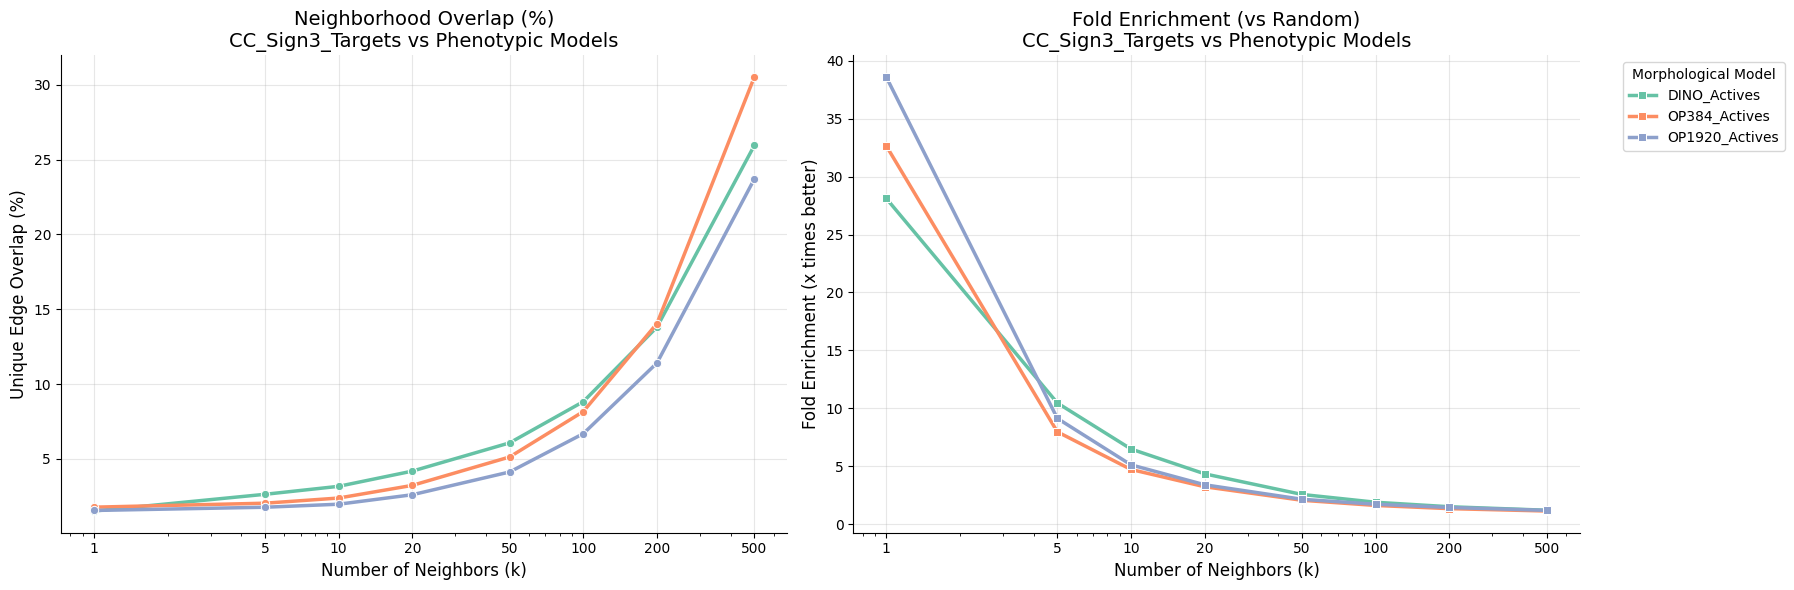


🏆 TOP PHENOTYPIC MODELS AT K=10 (The 'Biological Target' Zone):


,Dataset_1,Dataset_2,Aligned_Molecules,Overlap_Pct,Random_Overlap,Fold_Enrichment,Likelihood_GT_Chance,P_Value
0,CC_Sign3_Targets,DINO_Actives,3167,3.16,0.4859%,6.5,>99.99%,0.00e+00
1,CC_Sign3_Targets,OP1920_Actives,4416,1.96,0.382%,5.1,>99.99%,7.68e-230
2,CC_Sign3_Targets,OP384_Actives,3137,2.37,0.5016%,4.7,>99.99%,3.75e-182


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from scipy.stats import hypergeom
from tqdm import tqdm
import itertools
import time
import gc

# =====================================================================
# 1. DATASET CONFIGURATION
# =====================================================================
print("🗄️ Step 1: Configuring Target Datasets...")

# Minimol is removed; strictly comparing Targets vs Morphology!
datasets_config = {
    'CC_Sign3_Targets': 'gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/parquets/JUMPCP_Sign3_CC_final.parquet',
    'DINO_Actives': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/Bayer_DINO_embeddings_normed_final-actives_only.parquet',
    'OP384_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized-ACTIVE.parquet',
    'OP1920_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized-ACTIVE.parquet'
}

# =====================================================================
# 2. LOAD & STANDARDIZE ALL DATASETS INTO RAM
# =====================================================================
loaded_dfs = {}

def safely_set_inchikey_index(df, name):
    if df.index.name and 'inchikey' in str(df.index.name).lower():
        df.index.name = 'InChIKey'
        return df
    if df.index.name is None and isinstance(df.index[0], str) and len(str(df.index[0])) >= 25:
        df.index.name = 'InChIKey'
        return df
    inchikey_col = next((c for c in df.columns if 'inchikey' in c.lower()), None)
    if inchikey_col:
        df = df.set_index(inchikey_col)
        df.index.name = 'InChIKey'
        return df
    raise KeyError(f"Could not find an InChIKey column in {name}")

print("⚙️ Step 2: Loading and cleaning datasets...")
for name, path in tqdm(datasets_config.items(), desc="Loading Parquets"):
    try:
        df = pd.read_parquet(path)
        df = safely_set_inchikey_index(df, name)
        df = df[~df.index.duplicated(keep='first')]

        # Isolate pure numeric features
        df_embs = df.select_dtypes(include=[np.number]).astype(np.float32)
        loaded_dfs[name] = df_embs
    except Exception as e:
        print(f"   ❌ Failed to load {name}: {e}")

# =====================================================================
# 3. PAIRWISE KNN SWEEP WITH STATISTICAL SIGNIFICANCE
# =====================================================================
K_LIST = [1, 5, 10, 20, 50, 100, 200, 500]

dataset_names = list(loaded_dfs.keys())
combinations = list(itertools.combinations(dataset_names, 2))

print(f"\n🚀 Step 3: Running k-Sweep across {len(combinations)} dataset pairs...")

all_results = []

for name_A, name_B in tqdm(combinations, desc="Pairwise Align & kNN"):
    df_A = loaded_dfs[name_A]
    df_B = loaded_dfs[name_B]

    # 1. Align the pair dynamically
    df_A_aligned, df_B_aligned = df_A.align(df_B, join='inner', axis=0)
    df_A_aligned.fillna(0.0, inplace=True)
    df_B_aligned.fillna(0.0, inplace=True)

    num_molecules = len(df_A_aligned)

    valid_k_list = [k for k in K_LIST if k < num_molecules]
    if not valid_k_list:
        continue

    MAX_K = max(valid_k_list)
    X = df_A_aligned.values
    Y = df_B_aligned.values
    total_possible_pairs = int((num_molecules * (num_molecules - 1)) / 2)

    # 2. Fit KNN once for MAX_K
    knn_X = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(X)
    knn_Y = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(Y)

    _, indices_X_full = knn_X.kneighbors(X)
    _, indices_Y_full = knn_Y.kneighbors(Y)

    # 3. Evaluate each K
    for k in valid_k_list:
        current_rows = np.repeat(np.arange(num_molecules), k)

        # Deduplicated edges for Space X
        cols_X = indices_X_full[:, 1:k+1].flatten()
        min_X, max_X = np.minimum(current_rows, cols_X), np.maximum(current_rows, cols_X)
        unique_edges_X = { (u, v) for u, v in zip(min_X, max_X) if u != v }

        # Deduplicated edges for Space Y
        cols_Y = indices_Y_full[:, 1:k+1].flatten()
        min_Y, max_Y = np.minimum(current_rows, cols_Y), np.maximum(current_rows, cols_Y)
        unique_edges_Y = { (u, v) for u, v in zip(min_Y, max_Y) if u != v }

        # Intersection
        num_shared = len(unique_edges_X.intersection(unique_edges_Y))
        overlap_pct = num_shared / len(unique_edges_X) if len(unique_edges_X) > 0 else 0
        random_expected = len(unique_edges_Y) / total_possible_pairs
        fold_enrichment = overlap_pct / random_expected if random_expected > 0 else 0

        # 4. Statistical Likelihood (Hypergeometric Test)
        drawn = len(unique_edges_X)
        successes_in_pop = len(unique_edges_Y)

        if num_shared > 0 and drawn > 0:
            p_val = hypergeom.sf(num_shared - 1, total_possible_pairs, successes_in_pop, drawn)
        else:
            p_val = 1.0

        likelihood_pct = (1.0 - p_val) * 100
        likelihood_str = ">99.99%" if p_val < 1e-4 else f"{likelihood_pct:.2f}%"

        all_results.append({
            'Dataset_1': name_A,
            'Dataset_2': name_B,
            'Aligned_Molecules': num_molecules,
            'k': k,
            'Overlap_Pct': overlap_pct * 100,
            'Random_Overlap': random_expected * 100,
            'Fold_Enrichment': fold_enrichment,
            'P_Value': p_val,
            'Likelihood_GT_Chance': likelihood_str
        })

    del df_A_aligned, df_B_aligned, X, Y, knn_X, knn_Y, indices_X_full, indices_Y_full
    gc.collect()

df_results = pd.DataFrame(all_results)

# =====================================================================
# 4. VISUALIZE THE RESULTS
# =====================================================================
print("\n🎨 Step 4: Generating K-Sweep Visualizations...")

colors = sns.color_palette("Set2", 8)

def plot_dual_metrics(df, anchor_name):
    df_anchor = df[(df['Dataset_1'] == anchor_name) | (df['Dataset_2'] == anchor_name)].copy()
    if df_anchor.empty: return

    df_anchor['Comparison'] = np.where(
        df_anchor['Dataset_1'] == anchor_name, df_anchor['Dataset_2'], df_anchor['Dataset_1']
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- Plot 1: Raw Overlap Percentage ---
    sns.lineplot(data=df_anchor, x='k', y='Overlap_Pct', hue='Comparison',
                 marker='o', linewidth=2.5, palette=colors, ax=axes[0])
    axes[0].set_xscale('log')
    axes[0].set_xticks(K_LIST)
    axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axes[0].set_title(f'Neighborhood Overlap (%)\n{anchor_name} vs Phenotypic Models', fontsize=14)
    axes[0].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[0].set_ylabel('Unique Edge Overlap (%)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].get_legend().remove()

    # --- Plot 2: Fold Enrichment ---
    sns.lineplot(data=df_anchor, x='k', y='Fold_Enrichment', hue='Comparison',
                 marker='s', linewidth=2.5, palette=colors, ax=axes[1])
    axes[1].set_xscale('log')
    axes[1].set_xticks(K_LIST)
    axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axes[1].set_title(f'Fold Enrichment (vs Random)\n{anchor_name} vs Phenotypic Models', fontsize=14)
    axes[1].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[1].set_ylabel('Fold Enrichment (x times better)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Morphological Model")

    sns.despine()
    plt.tight_layout()
    plt.show()

# Generate plots anchoring on Biological Targets (Chemical Checker)
plot_dual_metrics(df_results, anchor_name='CC_Sign3_Targets')

# =====================================================================
# 5. SUMMARY OF TOP RESULTS WITH STATISTICAL SIGNIFICANCE
# =====================================================================
print("\n🏆 TOP PHENOTYPIC MODELS AT K=10 (The 'Biological Target' Zone):")
print("=" * 125)

# Filter for k=10, focusing on comparisons involving the Chemical Checker
k10_df_cc = df_results[(df_results['k'] == 10) &
                    ((df_results['Dataset_1'] == 'CC_Sign3_Targets') |
                     (df_results['Dataset_2'] == 'CC_Sign3_Targets'))].sort_values(by='Fold_Enrichment', ascending=False)

# Format the P-Value column nicely for scientific notation
k10_df_cc['P_Value'] = k10_df_cc['P_Value'].apply(lambda x: f"{x:.2e}")

display_cols = ['Dataset_1', 'Dataset_2', 'Aligned_Molecules', 'Overlap_Pct', 'Random_Overlap', 'Fold_Enrichment', 'Likelihood_GT_Chance', 'P_Value']

# Round the standard numeric columns for clean display
display_df_cc = k10_df_cc[display_cols].copy()
display_df_cc['Overlap_Pct'] = display_df_cc['Overlap_Pct'].round(2)

# Keep Random_Overlap at 4 decimal places
display_df_cc['Random_Overlap'] = display_df_cc['Random_Overlap'].round(4).astype(str) + '%'
display_df_cc['Fold_Enrichment'] = display_df_cc['Fold_Enrichment'].round(1)

display(display_df_cc.reset_index(drop=True))

kNN inspector

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import gc

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
# Choose which two spaces you want to inspect!
SPACE_A_NAME = 'Minimol'             # E.g. Chemical Structure
SPACE_B_NAME = 'OP1920_Norm_Actives' # E.g. Cell Morphology

K_NEIGHBORS = 10
MIN_SHARED_NEIGHBORS = 4 # Only show molecules sharing >= 4 of their top 10 neighbors

datasets_config = {
    'Minimol': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__Kim_et_al_subset_final.parquet',
    'CC_Sign2': 'gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/parquets/JUMPCP_CC_Sign2_Global_Signatures.parquet',
    'CC_Sign3': 'gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/parquets/JUMPCP_Sign3_CC_final.parquet',
    'DINO_Raw': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_nonorm_final.parquet',
    'DINO_Norm': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_normed_final.parquet',
    'DINO_Norm_Actives': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/Bayer_DINO_embeddings_normed_final-actives_only.parquet',
    'OP384_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384.parquet',
    'OP384_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized.parquet',
    'OP1920_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920.parquet',
    'OP1920_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized.parquet',
    'OP384_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized-ACTIVE.parquet',
    'OP1920_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized-ACTIVE.parquet'
}

# =====================================================================
# 2. HELPER FUNCTION: AUTO-DETECT IDENTIFIERS
# =====================================================================
def safely_set_inchikey_index(df, name):
    if df.index.name and 'inchikey' in str(df.index.name).lower():
        df.index.name = 'InChIKey'
        return df
    if df.index.name is None and isinstance(df.index[0], str) and len(str(df.index[0])) >= 25:
        df.index.name = 'InChIKey'
        return df
    inchikey_col = next((c for c in df.columns if 'inchikey' in c.lower()), None)
    if inchikey_col:
        df = df.set_index(inchikey_col)
        df.index.name = 'InChIKey'
        return df
    raise KeyError(f"❌ Could not find an InChIKey column in {name}! Available columns: {list(df.columns[:15])}")

# =====================================================================
# 3. LOAD & STANDARDIZE ALL DATASETS INTO RAM
# =====================================================================
print("⚙️ Step 1: Loading and cleaning datasets into RAM...")
loaded_dfs = {}

for name, path in tqdm(datasets_config.items(), desc="Loading Parquets"):
    try:
        df = pd.read_parquet(path)
        df = safely_set_inchikey_index(df, name)
        df = df[~df.index.duplicated(keep='first')]
        df_embs = df.select_dtypes(include=[np.number]).astype(np.float32)
        loaded_dfs[name] = df_embs
        del df
        gc.collect()
    except Exception as e:
        print(f"   ❌ Failed to load {name}: {e}")

# =====================================================================
# 4. ALIGN TARGET DATASETS
# =====================================================================
print(f"\n🔍 Step 2: Inspecting highly conserved neighborhoods between {SPACE_A_NAME} and {SPACE_B_NAME}...")

if SPACE_A_NAME not in loaded_dfs or SPACE_B_NAME not in loaded_dfs:
    raise KeyError("One or both target datasets failed to load. Check paths and spelling!")

df_A = loaded_dfs[SPACE_A_NAME]
df_B = loaded_dfs[SPACE_B_NAME]

print(f"   -> Aligning molecules...")
df_A_aligned, df_B_aligned = df_A.align(df_B, join='inner', axis=0)
df_A_aligned.fillna(0.0, inplace=True)
df_B_aligned.fillna(0.0, inplace=True)

inchikeys = df_A_aligned.index.values
X = df_A_aligned.values
Y = df_B_aligned.values

num_molecules = len(inchikeys)
print(f"   ✅ Analyzing {num_molecules:,} shared molecules.")

if num_molecules < K_NEIGHBORS:
    raise ValueError("Not enough overlapping molecules to run KNN!")

# =====================================================================
# 5. FIT KNN & QUERY DISTANCES
# =====================================================================
print(f"   -> Finding Top {K_NEIGHBORS} neighbors in both spaces...")

knn_X = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric='cosine', n_jobs=-1).fit(X)
knn_Y = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric='cosine', n_jobs=-1).fit(Y)

_, indices_X = knn_X.kneighbors(X)
_, indices_Y = knn_Y.kneighbors(Y)

# =====================================================================
# 6. FIND HIGH-OVERLAP MOLECULES & IDENTIFY NEIGHBORS
# =====================================================================
print(f"   -> Extracting exact shared molecules...")

high_overlap_records = []

for i in range(num_molecules):
    query_key = inchikeys[i]

    # Slice [1:] to skip the query molecule itself
    neighbors_X = set(indices_X[i][1:])
    neighbors_Y = set(indices_Y[i][1:])

    # Find the indices that exist in BOTH top-K lists
    shared_indices = neighbors_X.intersection(neighbors_Y)

    if len(shared_indices) >= MIN_SHARED_NEIGHBORS:
        # Convert those indices back into actual InChIKeys
        shared_keys = [inchikeys[idx] for idx in shared_indices]

        high_overlap_records.append({
            'Query_InChIKey': query_key,
            'Overlap_Count': len(shared_indices),
            'Overlap_Pct': f"{(len(shared_indices)/K_NEIGHBORS)*100:.0f}%",
            'Shared_Neighbor_InChIKeys': " | ".join(shared_keys)
        })

# =====================================================================
# 7. DISPLAY RESULTS
# =====================================================================
if not high_overlap_records:
    print(f"\n🛑 No molecules found sharing >= {MIN_SHARED_NEIGHBORS} neighbors. Try lowering MIN_SHARED_NEIGHBORS.")
else:
    # Convert to DataFrame and sort by the highest overlap count
    df_high_overlap = pd.DataFrame(high_overlap_records).sort_values(by='Overlap_Count', ascending=False)

    print("\n🏆 RESULTS: HIGHLY CONSERVED NEIGHBORHOODS")
    print("=" * 100)
    print(f"   Found {len(df_high_overlap):,} molecules preserving >= {MIN_SHARED_NEIGHBORS} out of {K_NEIGHBORS} neighbors.")
    print("=" * 100)

    # Adjust Pandas display settings temporarily to show the full list of shared keys
    with pd.option_context('display.max_colwidth', None):
        display(df_high_overlap.head(20).reset_index(drop=True))

⚙️ Step 1: Loading and cleaning datasets into RAM...


Loading Parquets: 100%|██████████| 12/12 [00:24<00:00,  2.07s/it]



🔍 Step 2: Inspecting highly conserved neighborhoods between Minimol and OP1920_Norm_Actives...
   -> Aligning molecules...
   ✅ Analyzing 8,257 shared molecules.
   -> Finding Top 10 neighbors in both spaces...
   -> Extracting exact shared molecules...

🏆 RESULTS: HIGHLY CONSERVED NEIGHBORHOODS
   Found 31 molecules preserving >= 4 out of 10 neighbors.


,Query_InChIKey,Overlap_Count,Overlap_Pct,Shared_Neighbor_InChIKeys
0,RVEFWDFDCPPOIN-UHFFFAOYSA-N,6,60%,ZFUPNSFODRGWDL-UHFFFAOYSA-N | RQALGBOYFSWXNZ-UHFFFAOYSA-N | UQCPLKYCEZJXES-UHFFFAOYSA-N | GUGKZZCJXZJTGZ-UHFFFAOYSA-N | WUYUBRRFSCEXCC-UHFFFAOYSA-N | AFVWPXYESDXYSF-UHFFFAOYSA-N
1,YFUMYYFNOGYCID-UHFFFAOYSA-N,6,60%,XGFCZMZUYXIJPI-UHFFFAOYSA-N | INWHPCXSCLMRSP-UHFFFAOYSA-N | WHSLYRNFVNFEGC-UHFFFAOYSA-N | AMWRDDJWWIFEQP-UHFFFAOYSA-N | IRIORZFQAWBTPY-UHFFFAOYSA-N | YFKMDNGNDUJNHO-UHFFFAOYSA-N
2,YFKMDNGNDUJNHO-UHFFFAOYSA-N,6,60%,XGFCZMZUYXIJPI-UHFFFAOYSA-N | INWHPCXSCLMRSP-UHFFFAOYSA-N | WHSLYRNFVNFEGC-UHFFFAOYSA-N | YFUMYYFNOGYCID-UHFFFAOYSA-N | AMWRDDJWWIFEQP-UHFFFAOYSA-N | IRIORZFQAWBTPY-UHFFFAOYSA-N
3,AMWRDDJWWIFEQP-UHFFFAOYSA-N,6,60%,XGFCZMZUYXIJPI-UHFFFAOYSA-N | INWHPCXSCLMRSP-UHFFFAOYSA-N | WHSLYRNFVNFEGC-UHFFFAOYSA-N | YFUMYYFNOGYCID-UHFFFAOYSA-N | IRIORZFQAWBTPY-UHFFFAOYSA-N | YFKMDNGNDUJNHO-UHFFFAOYSA-N
4,WHSLYRNFVNFEGC-UHFFFAOYSA-N,6,60%,XGFCZMZUYXIJPI-UHFFFAOYSA-N | INWHPCXSCLMRSP-UHFFFAOYSA-N | YFUMYYFNOGYCID-UHFFFAOYSA-N | AMWRDDJWWIFEQP-UHFFFAOYSA-N | IRIORZFQAWBTPY-UHFFFAOYSA-N | YFKMDNGNDUJNHO-UHFFFAOYSA-N
5,IGQLXQIACPBUOG-UHFFFAOYSA-N,6,60%,RGRMLRFENXCEQZ-UHFFFAOYSA-N | AEARWLUTUOZVDZ-UHFFFAOYSA-N | ZZKVKZXKXQDPIU-UHFFFAOYSA-N | CKOOOUJCBSESEQ-UHFFFAOYSA-N | LPOURIRVYISKKC-UHFFFAOYSA-N | RSIBUZIDFDQQOE-UHFFFAOYSA-N
6,YOCJYBMQWMFFSG-UHFFFAOYSA-N,5,50%,ZFUPNSFODRGWDL-UHFFFAOYSA-N | RQALGBOYFSWXNZ-UHFFFAOYSA-N | UQCPLKYCEZJXES-UHFFFAOYSA-N | RVEFWDFDCPPOIN-UHFFFAOYSA-N | GUGKZZCJXZJTGZ-UHFFFAOYSA-N
7,UQCPLKYCEZJXES-UHFFFAOYSA-N,5,50%,ZFUPNSFODRGWDL-UHFFFAOYSA-N | RQALGBOYFSWXNZ-UHFFFAOYSA-N | RVEFWDFDCPPOIN-UHFFFAOYSA-N | GUGKZZCJXZJTGZ-UHFFFAOYSA-N | AFVWPXYESDXYSF-UHFFFAOYSA-N
8,INWHPCXSCLMRSP-UHFFFAOYSA-N,5,50%,XGFCZMZUYXIJPI-UHFFFAOYSA-N | WHSLYRNFVNFEGC-UHFFFAOYSA-N | YFUMYYFNOGYCID-UHFFFAOYSA-N | AMWRDDJWWIFEQP-UHFFFAOYSA-N | YFKMDNGNDUJNHO-UHFFFAOYSA-N
9,BMXAVXNMHFYUKX-UHFFFAOYSA-N,5,50%,XUIIEHGHJMBYKG-UHFFFAOYSA-N | CPUTYPQMRXQNFT-UHFFFAOYSA-N | AEARWLUTUOZVDZ-UHFFFAOYSA-N | LPOURIRVYISKKC-UHFFFAOYSA-N | RSIBUZIDFDQQOE-UHFFFAOYSA-N


📂 Step 1: Loading target subset from gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_clusters.csv...
🧹 Dropped 8,856 noise molecules (Cluster -1).
✅ Kept 749 strongly clustered molecules.

📊 DEBUG: FILTERED SUBSET CSV
   Total Rows:    749


,Metadata_InChIKey,HDBSCAN_Cluster_ID,UMAP_X,UMAP_Y,Metadata_JCP2022_x,SMILES_standard,Metadata_JCP2022_y,Metadata_InChI,Metadata_SMILES
0,JWWQHMUSBJSOKZ-UHFFFAOYSA-N,0,-2.528812,-0.993411,JCP2022_042659,Cc1cc(=O)n2cccc(O)c2n1,JCP2022_042659,InChI=1S/C9H8N2O2/c1-6-5-8(13)11-4-2-3-7(12)9(...,Cc1cc(=O)n2cccc(O)c2n1
1,FJIQQZXHNOTAEI-UHFFFAOYSA-N,0,-1.565654,-0.930713,JCP2022_021023,Cn1nc(CC(=O)O)c2ccccc2c1=O,JCP2022_021023,InChI=1S/C11H10N2O3/c1-13-11(16)8-5-3-2-4-7(8)...,Cn1nc(CC(=O)O)c2ccccc2c1=O
2,XDMONCLSHJEVSR-UHFFFAOYSA-N,0,-1.425264,-0.780881,JCP2022_102966,CCn1c(=O)c(C)nc2cc(C(=O)O)ccc21,JCP2022_102966,InChI=1S/C12H12N2O3/c1-3-14-10-5-4-8(12(16)17)...,CCn1c(=O)c(C)nc2cc(C(=O)O)ccc21



✅ Extracted 749 unique target identifiers.
   -> Example keys: ['FKOKOJREXZYLQF-UHFFFAOYSA-N', 'SLXKOJJOQWFEFD-UHFFFAOYSA-N', 'YGSDEFSMJLZEOE-UHFFFAOYSA-N']

🗄️ Step 2: Configuring Datasets...

⚙️ Step 3: Loading, cleaning, and filtering datasets...


Loading Parquets: 100%|██████████| 10/10 [00:19<00:00,  1.99s/it]



🚀 Step 4: Running deduplicated k-Sweep across 9 targeted pairs...


Pairwise Align & kNN: 100%|██████████| 9/9 [00:11<00:00,  1.28s/it]



🎨 Step 5: Generating Master k-Sweep Visualizations...


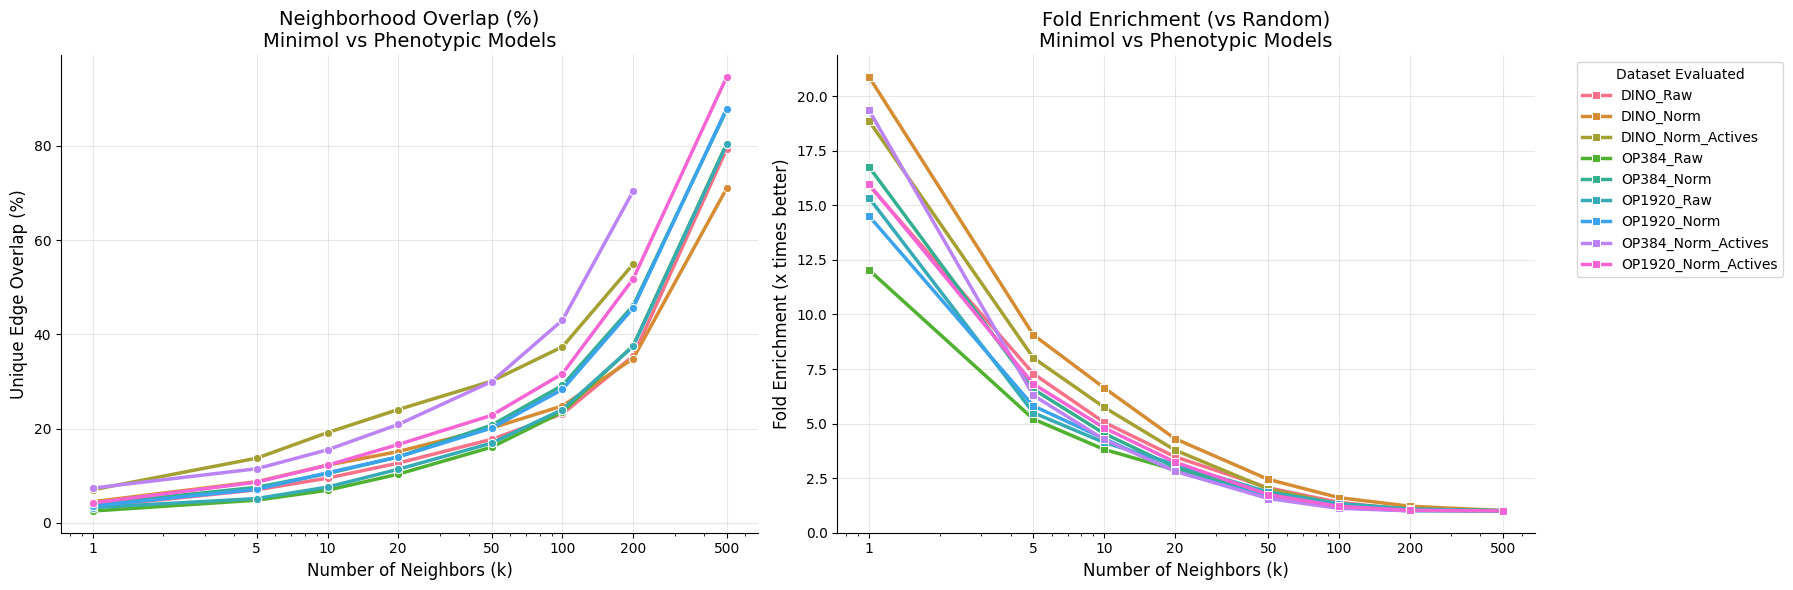


🏆 TOP PHENOTYPIC MODELS AT K=10 (The 'Pharmacological Family' Zone):


,Dataset_1,Dataset_2,Aligned_Molecules,Overlap_Pct,Random_Overlap,Fold_Enrichment,Likelihood_GT_Chance,P_Value
0,Minimol,DINO_Norm,749,12.24,1.8431%,6.6,>99.99%,6.78e-301
1,Minimol,DINO_Norm_Actives,440,19.15,3.3309%,5.8,>99.99%,3.89e-252
2,Minimol,DINO_Raw,749,9.49,1.8759%,5.1,>99.99%,7.53e-182
3,Minimol,OP1920_Norm_Actives,641,12.23,2.5444%,4.8,>99.99%,5.71e-193
4,Minimol,OP384_Norm,749,10.46,2.3008%,4.5,>99.99%,1.34e-180
5,Minimol,OP1920_Norm,749,10.62,2.4628%,4.3,>99.99%,1.79e-173
6,Minimol,OP384_Norm_Actives,428,15.50,3.6289%,4.3,>99.99%,2.05e-147
7,Minimol,OP1920_Raw,749,7.59,1.8352%,4.1,>99.99%,2.89e-117
8,Minimol,OP384_Raw,749,6.92,1.8128%,3.8,>99.99%,2.28e-97


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from scipy.stats import hypergeom
from tqdm import tqdm
import itertools
import time
import gc

# =====================================================================
# 1. LOAD TARGET SUBSET & DROP NOISE
# =====================================================================
subset_csv = 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_clusters.csv'

print(f"📂 Step 1: Loading target subset from {subset_csv}...")
df_subset = pd.read_csv(subset_csv)

# ---> NEW: DROP NOISE CLUSTERS ON LOAD <---
if 'HDBSCAN_Cluster_ID' in df_subset.columns:
    initial_count = len(df_subset)
    df_subset = df_subset[df_subset['HDBSCAN_Cluster_ID'] != -1].copy()
    dropped_count = initial_count - len(df_subset)
    print(f"🧹 Dropped {dropped_count:,} noise molecules (Cluster -1).")
    print(f"✅ Kept {len(df_subset):,} strongly clustered molecules.")

print("\n" + "="*80)
print(f"📊 DEBUG: FILTERED SUBSET CSV")
print(f"   Total Rows:    {len(df_subset):,}")
print("="*80)
display(df_subset.head(3))
print("="*80 + "\n")

# Safely auto-detect the identifier column (Looking for InChIKey)
inchikey_col = next((c for c in df_subset.columns if 'inchikey' in c.lower()), None)
if not inchikey_col:
    # Strict fallback to prevent it from accidentally grabbing the Cluster_ID column!
    raise KeyError(f"❌ Could not find an 'InChIKey' column in your subset CSV. Available columns: {list(df_subset.columns)}")

# Extract the target keys
target_keys = set(df_subset[inchikey_col].dropna().astype(str).str.strip())
print(f"✅ Extracted {len(target_keys):,} unique target identifiers.")
print(f"   -> Example keys: {list(target_keys)[:3]}")

# =====================================================================
# 2. DATASET CONFIGURATION
# =====================================================================
print("\n🗄️ Step 2: Configuring Datasets...")

datasets_config = {
    'Minimol': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__Kim_et_al_subset_final.parquet',
    'DINO_Raw': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_nonorm_final.parquet',
    'DINO_Norm': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_normed_final.parquet',
    'DINO_Norm_Actives': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/Bayer_DINO_embeddings_normed_final-actives_only.parquet',
    'OP384_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384.parquet',
    'OP384_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized.parquet',
    'OP1920_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920.parquet',
    'OP1920_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized.parquet',
    'OP384_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized-ACTIVE.parquet',
    'OP1920_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized-ACTIVE.parquet'
}

# =====================================================================
# 3. LOAD & FILTER ALL DATASETS INTO RAM
# =====================================================================
loaded_dfs = {}

def safely_set_inchikey_index(df, name):
    if df.index.name and 'inchikey' in str(df.index.name).lower():
        df.index.name = 'InChIKey'
        return df
    if df.index.name is None and isinstance(df.index[0], str) and len(str(df.index[0])) >= 25:
        df.index.name = 'InChIKey'
        return df
    inchikey_col_df = next((c for c in df.columns if 'inchikey' in c.lower()), None)
    if inchikey_col_df:
        df = df.set_index(inchikey_col_df)
        df.index.name = 'InChIKey'
        return df
    raise KeyError(f"Could not find an InChIKey column in {name}")

print("\n⚙️ Step 3: Loading, cleaning, and filtering datasets...")
for name, path in tqdm(datasets_config.items(), desc="Loading Parquets"):
    try:
        df = pd.read_parquet(path)
        df = safely_set_inchikey_index(df, name)

        # 🚨 FILTER: Keep ONLY the molecules present in the clustered subset!
        valid_keys = df.index.intersection(target_keys)
        df = df.loc[valid_keys]

        df = df[~df.index.duplicated(keep='first')]

        # Isolate pure numeric features to keep RAM usage incredibly low
        df_embs = df.select_dtypes(include=[np.number]).astype(np.float32)

        if len(df_embs) > 0:
            loaded_dfs[name] = df_embs
        else:
            print(f"   ⚠️ {name} resulted in 0 matching molecules. It will be skipped.")
    except Exception as e:
        print(f"   ❌ Failed to load {name}: {e}")

if not loaded_dfs:
    raise ValueError("\n🛑 CRITICAL ERROR: All datasets resulted in 0 matching molecules! The target identifiers from your CSV do not match the InChIKeys in the Parquet files.")

# =====================================================================
# 4. TARGETED PAIRWISE KNN SWEEP
# =====================================================================
K_LIST = [1, 5, 10, 20, 50, 100, 200, 500]

dataset_names = list(loaded_dfs.keys())
combinations = [('Minimol', name) for name in dataset_names if name != 'Minimol']

print(f"\n🚀 Step 4: Running deduplicated k-Sweep across {len(combinations)} targeted pairs...")

all_results = []

for name_A, name_B in tqdm(combinations, desc="Pairwise Align & kNN"):
    if name_A not in loaded_dfs or name_B not in loaded_dfs:
        continue

    df_A = loaded_dfs[name_A]
    df_B = loaded_dfs[name_B]

    # 1. Align the pair dynamically
    df_A_aligned, df_B_aligned = df_A.align(df_B, join='inner', axis=0)
    df_A_aligned.fillna(0.0, inplace=True)
    df_B_aligned.fillna(0.0, inplace=True)

    num_molecules = len(df_A_aligned)

    valid_k_list = [k for k in K_LIST if k < num_molecules]
    if not valid_k_list:
        continue

    MAX_K = max(valid_k_list)
    X = df_A_aligned.values
    Y = df_B_aligned.values
    total_possible_pairs = (num_molecules * (num_molecules - 1)) / 2

    # 2. Fit KNN
    knn_X = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(X)
    knn_Y = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(Y)

    _, indices_X_full = knn_X.kneighbors(X)
    _, indices_Y_full = knn_Y.kneighbors(Y)

    # 3. Evaluate each K
    for k in valid_k_list:
        current_rows = np.repeat(np.arange(num_molecules), k)

        cols_X = indices_X_full[:, 1:k+1].flatten()
        min_X, max_X = np.minimum(current_rows, cols_X), np.maximum(current_rows, cols_X)
        unique_edges_X = { (u, v) for u, v in zip(min_X, max_X) if u != v }

        cols_Y = indices_Y_full[:, 1:k+1].flatten()
        min_Y, max_Y = np.minimum(current_rows, cols_Y), np.maximum(current_rows, cols_Y)
        unique_edges_Y = { (u, v) for u, v in zip(min_Y, max_Y) if u != v }

        num_shared = len(unique_edges_X.intersection(unique_edges_Y))
        overlap_pct = num_shared / len(unique_edges_X) if len(unique_edges_X) > 0 else 0
        random_expected = len(unique_edges_Y) / total_possible_pairs if total_possible_pairs > 0 else 0
        fold_enrichment = overlap_pct / random_expected if random_expected > 0 else 0

        drawn = len(unique_edges_X)
        successes_in_pop = len(unique_edges_Y)
        if num_shared > 0 and drawn > 0:
            p_val = hypergeom.sf(num_shared - 1, total_possible_pairs, successes_in_pop, drawn)
        else:
            p_val = 1.0

        likelihood_pct = (1.0 - p_val) * 100
        likelihood_str = ">99.99%" if p_val < 1e-4 else f"{likelihood_pct:.2f}%"

        all_results.append({
            'Dataset_1': name_A,
            'Dataset_2': name_B,
            'Aligned_Molecules': num_molecules,
            'k': k,
            'Overlap_Pct': overlap_pct * 100,
            'Random_Overlap': random_expected * 100,
            'Fold_Enrichment': fold_enrichment,
            'Likelihood_GT_Chance': likelihood_str,
            'P_Value': p_val
        })

    del df_A_aligned, df_B_aligned, X, Y, knn_X, knn_Y, indices_X_full, indices_Y_full
    gc.collect()

# 🚨 Ensure we actually have results before plotting
if not all_results:
    raise ValueError("\n🛑 CRITICAL ERROR: The kNN sweep returned no results. No molecules were properly aligned.")

df_results = pd.DataFrame(all_results)

# =====================================================================
# 5. VISUALIZE THE K-SWEEPS
# =====================================================================
print("\n🎨 Step 5: Generating Master k-Sweep Visualizations...")

colors = sns.color_palette("husl", len(combinations))

def plot_anchor_sweep(df, anchor_name, metric='Fold_Enrichment', metric_label='Fold Enrichment'):
    df_anchor = df[(df['Dataset_1'] == anchor_name) | (df['Dataset_2'] == anchor_name)].copy()

    if df_anchor.empty:
        print(f"⚠️ No successful alignments found for {anchor_name}.")
        return

    df_anchor['Comparison'] = np.where(
        df_anchor['Dataset_1'] == anchor_name,
        df_anchor['Dataset_2'],
        df_anchor['Dataset_1']
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- Plot 1: Raw Overlap Percentage ---
    sns.lineplot(data=df_anchor, x='k', y='Overlap_Pct', hue='Comparison',
                 marker='o', linewidth=2.5, palette=colors, ax=axes[0])
    axes[0].set_xscale('log')
    axes[0].set_xticks(K_LIST)
    axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axes[0].set_title(f'Neighborhood Overlap (%)\n{anchor_name} vs Phenotypic Models', fontsize=14)
    axes[0].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[0].set_ylabel('Unique Edge Overlap (%)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].get_legend().remove()

    # --- Plot 2: Fold Enrichment ---
    sns.lineplot(data=df_anchor, x='k', y=metric, hue='Comparison',
                 marker='s', linewidth=2.5, palette=colors, ax=axes[1])
    axes[1].set_xscale('log')
    axes[1].set_xticks(K_LIST)
    axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axes[1].set_title(f'{metric_label} (vs Random)\n{anchor_name} vs Phenotypic Models', fontsize=14)
    axes[1].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[1].set_ylabel(f'{metric_label} (x times better)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Dataset Evaluated")

    sns.despine()
    plt.tight_layout()
    plt.show()

# --- Plot the Sweep ---
plot_anchor_sweep(df_results, anchor_name='Minimol', metric='Fold_Enrichment', metric_label='Fold Enrichment')

# =====================================================================
# 6. SUMMARY OF TOP RESULTS WITH STATISTICAL SIGNIFICANCE
# =====================================================================
print("\n🏆 TOP PHENOTYPIC MODELS AT K=10 (The 'Pharmacological Family' Zone):")
print("=" * 125)

# Filter for k=10
k10_df = df_results[df_results['k'] == 10].sort_values(by='Fold_Enrichment', ascending=False)
k10_df['P_Value'] = k10_df['P_Value'].apply(lambda x: f"{x:.2e}")

display_cols = ['Dataset_1', 'Dataset_2', 'Aligned_Molecules', 'Overlap_Pct', 'Random_Overlap', 'Fold_Enrichment', 'Likelihood_GT_Chance', 'P_Value']

display_df = k10_df[display_cols].copy()
display_df['Overlap_Pct'] = display_df['Overlap_Pct'].round(2)
display_df['Random_Overlap'] = display_df['Random_Overlap'].round(4).astype(str) + '%'
display_df['Fold_Enrichment'] = display_df['Fold_Enrichment'].round(1)

display(display_df.reset_index(drop=True))

📂 Step 1: Loading target subset from gs://calico-reference-embeddings/Chemical_Checker_Embeddings/parquets/sign3_clusters.csv...
🧹 Dropped 20,029 noise molecules (Cluster -1).
✅ Kept 1,436 strongly clustered molecules.

📊 DEBUG: FILTERED SUBSET CSV
   Total Rows:    1,436


,HDBSCAN_Cluster_ID,UMAP_X,UMAP_Y,Metadata_JCP2022,InChIKey,Metadata_InChI,Metadata_SMILES,SMILES_standard
0,0,-4.540666,-5.586490,JCP2022_101592,WWCXWQKUYMDYSQ-UHFFFAOYSA-N,InChI=1S/C20H26O6/c1-25-17-11-13(5-3-7-21)9-15...,COc1cc(CCCO)cc(-c2cc(CCCO)cc(OC)c2O)c1O,COc1cc(CCCO)cc(-c2cc(CCCO)cc(OC)c2O)c1O
1,0,-4.527115,-5.584211,JCP2022_101630,WWKKOAKRYQQEBT-UHFFFAOYSA-N,InChI=1S/C25H22N4O4/c1-33-21-9-5-4-8-20(21)28-...,COc1ccccc1NC(=O)c1ccc(NC(=O)CCc2nc(=O)c3ccccc3...,COc1ccccc1NC(=O)c1ccc(NC(=O)CCc2nc(=O)c3ccccc3...
2,0,-4.545469,-5.592971,JCP2022_104756,XNKSDYBDUSFGDT-UHFFFAOYSA-N,InChI=1S/C20H25N3O2/c1-25-18-9-5-3-6-15(18)14-...,COc1ccccc1C1CCN(c2nc(=O)c3c([nH]2)CCCC3)CC1,COc1ccccc1C1CCN(c2nc(=O)c3c([nH]2)CCCC3)CC1



✅ Extracted 1,436 unique target identifiers.
   -> Example keys: ['GDWSSDDJVPAHDO-UHFFFAOYSA-N', 'NKGPJODWTZCHGF-UHFFFAOYSA-N', 'AKKCGLXULFRAET-UHFFFAOYSA-N']

🗄️ Step 2: Configuring Datasets...

⚙️ Step 3: Loading, cleaning, and filtering datasets...


Loading Parquets: 100%|██████████| 10/10 [00:17<00:00,  1.75s/it]



🚀 Step 4: Running deduplicated k-Sweep across 9 targeted pairs...


Pairwise Align & kNN: 100%|██████████| 9/9 [00:05<00:00,  1.60it/s]



🎨 Step 5: Generating Master k-Sweep Visualizations...


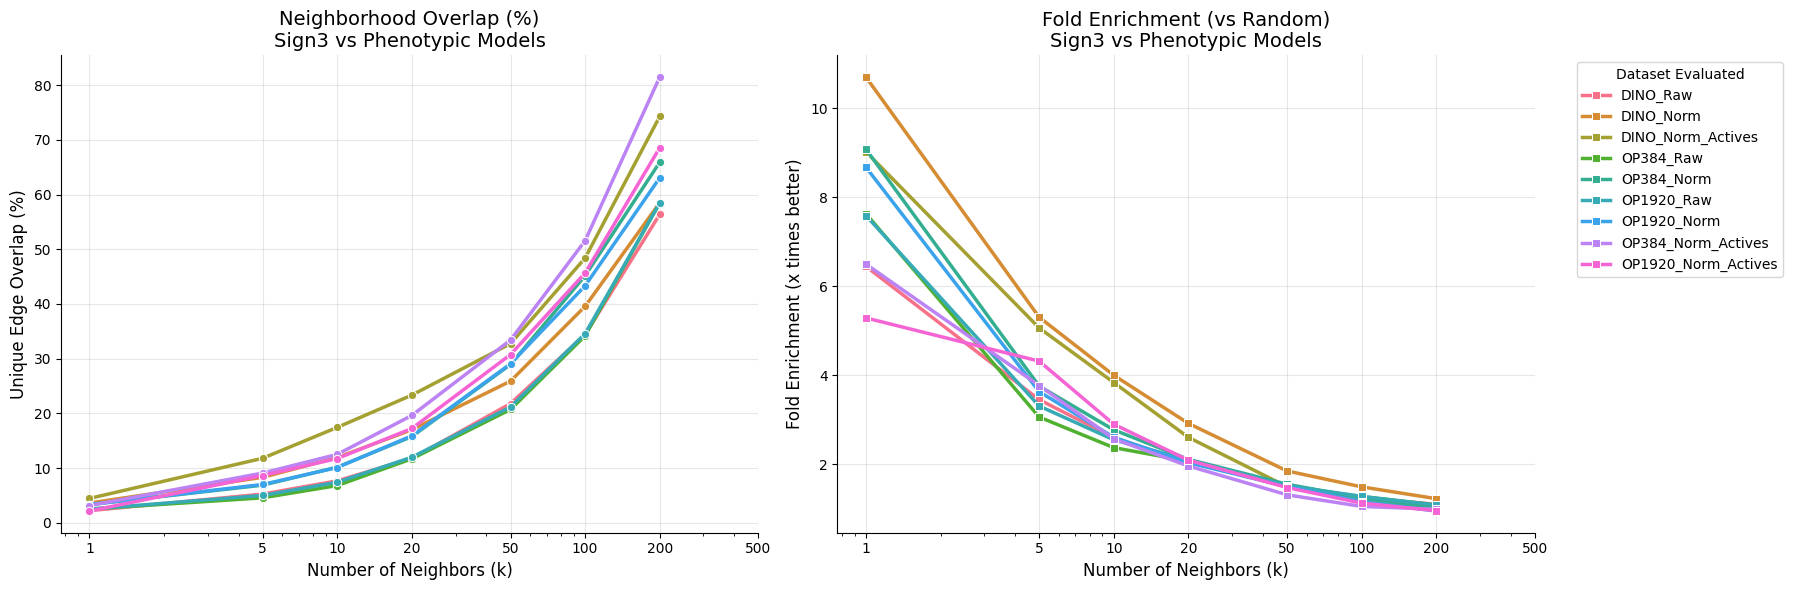


🏆 TOP PHENOTYPIC MODELS AT K=10 (The 'Pharmacological Family' Zone):


,Dataset_1,Dataset_2,Aligned_Molecules,Overlap_Pct,Random_Overlap,Fold_Enrichment,Likelihood_GT_Chance,P_Value
0,Sign3,DINO_Norm,472,11.93,2.9796%,4.0,>99.99%,7.97e-117
1,Sign3,DINO_Norm_Actives,327,17.44,4.5421%,3.8,>99.99%,2.77e-117
2,Sign3,OP1920_Norm_Actives,424,11.75,4.0479%,2.9,>99.99%,6.18e-68
3,Sign3,OP384_Norm,472,10.17,3.6624%,2.8,>99.99%,2.68e-60
4,Sign3,OP1920_Norm,472,10.11,3.8729%,2.6,>99.99%,5.06e-54
5,Sign3,DINO_Raw,472,7.68,2.9517%,2.6,>99.99%,1.07e-40
6,Sign3,OP384_Norm_Actives,330,12.51,4.8577%,2.6,>99.99%,1.39e-46
7,Sign3,OP1920_Raw,472,7.42,2.9067%,2.6,>99.99%,4.19e-38
8,Sign3,OP384_Raw,472,6.81,2.8653%,2.4,>99.99%,8.86e-31


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from scipy.stats import hypergeom
from tqdm import tqdm
import itertools
import time
import gc

# =====================================================================
# 1. LOAD TARGET SUBSET & DROP NOISE
# =====================================================================
subset_csv = 'gs://calico-reference-embeddings/Chemical_Checker_Embeddings/parquets/sign3_clusters.csv'

print(f"📂 Step 1: Loading target subset from {subset_csv}...")
df_subset = pd.read_csv(subset_csv)

# ---> NEW: DROP NOISE CLUSTERS ON LOAD <---
if 'HDBSCAN_Cluster_ID' in df_subset.columns:
    initial_count = len(df_subset)
    df_subset = df_subset[df_subset['HDBSCAN_Cluster_ID'] != -1].copy()
    dropped_count = initial_count - len(df_subset)
    print(f"🧹 Dropped {dropped_count:,} noise molecules (Cluster -1).")
    print(f"✅ Kept {len(df_subset):,} strongly clustered molecules.")

print("\n" + "="*80)
print(f"📊 DEBUG: FILTERED SUBSET CSV")
print(f"   Total Rows:    {len(df_subset):,}")
print("="*80)
display(df_subset.head(3))
print("="*80 + "\n")

# Safely auto-detect the identifier column (Looking for InChIKey)
inchikey_col = next((c for c in df_subset.columns if 'inchikey' in c.lower()), None)
if not inchikey_col:
    # Strict fallback to prevent it from accidentally grabbing the Cluster_ID column!
    raise KeyError(f"❌ Could not find an 'InChIKey' column in your subset CSV. Available columns: {list(df_subset.columns)}")

# Extract the target keys
target_keys = set(df_subset[inchikey_col].dropna().astype(str).str.strip())
print(f"✅ Extracted {len(target_keys):,} unique target identifiers.")
print(f"   -> Example keys: {list(target_keys)[:3]}")

# =====================================================================
# 2. DATASET CONFIGURATION
# =====================================================================
print("\n🗄️ Step 2: Configuring Datasets...")

datasets_config = {
    #'Minimol': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__Kim_et_al_subset_final.parquet',
    'Sign3': 'gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/parquets/JUMPCP_Sign3_CC_final.parquet',
    'DINO_Raw': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_nonorm_final.parquet',
    'DINO_Norm': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_normed_final.parquet',
    'DINO_Norm_Actives': 'gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/Bayer_DINO_embeddings_normed_final-actives_only.parquet',
    'OP384_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384.parquet',
    'OP384_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized.parquet',
    'OP1920_Raw': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920.parquet',
    'OP1920_Norm': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized.parquet',
    'OP384_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized-ACTIVE.parquet',
    'OP1920_Norm_Actives': 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized-ACTIVE.parquet'
}

# =====================================================================
# 3. LOAD & FILTER ALL DATASETS INTO RAM
# =====================================================================
loaded_dfs = {}

def safely_set_inchikey_index(df, name):
    if df.index.name and 'inchikey' in str(df.index.name).lower():
        df.index.name = 'InChIKey'
        return df
    if df.index.name is None and isinstance(df.index[0], str) and len(str(df.index[0])) >= 25:
        df.index.name = 'InChIKey'
        return df
    inchikey_col_df = next((c for c in df.columns if 'inchikey' in c.lower()), None)
    if inchikey_col_df:
        df = df.set_index(inchikey_col_df)
        df.index.name = 'InChIKey'
        return df
    raise KeyError(f"Could not find an InChIKey column in {name}")

print("\n⚙️ Step 3: Loading, cleaning, and filtering datasets...")
for name, path in tqdm(datasets_config.items(), desc="Loading Parquets"):
    try:
        df = pd.read_parquet(path)
        df = safely_set_inchikey_index(df, name)

        # 🚨 FILTER: Keep ONLY the molecules present in the clustered subset!
        valid_keys = df.index.intersection(target_keys)
        df = df.loc[valid_keys]

        df = df[~df.index.duplicated(keep='first')]

        # Isolate pure numeric features to keep RAM usage incredibly low
        df_embs = df.select_dtypes(include=[np.number]).astype(np.float32)

        if len(df_embs) > 0:
            loaded_dfs[name] = df_embs
        else:
            print(f"   ⚠️ {name} resulted in 0 matching molecules. It will be skipped.")
    except Exception as e:
        print(f"   ❌ Failed to load {name}: {e}")

if not loaded_dfs:
    raise ValueError("\n🛑 CRITICAL ERROR: All datasets resulted in 0 matching molecules! The target identifiers from your CSV do not match the InChIKeys in the Parquet files.")

# =====================================================================
# 4. TARGETED PAIRWISE KNN SWEEP
# =====================================================================
K_LIST = [1, 5, 10, 20, 50, 100, 200, 500]

dataset_names = list(loaded_dfs.keys())
combinations = [('Sign3', name) for name in dataset_names if name != 'Sign3']

print(f"\n🚀 Step 4: Running deduplicated k-Sweep across {len(combinations)} targeted pairs...")

all_results = []

for name_A, name_B in tqdm(combinations, desc="Pairwise Align & kNN"):
    if name_A not in loaded_dfs or name_B not in loaded_dfs:
        continue

    df_A = loaded_dfs[name_A]
    df_B = loaded_dfs[name_B]

    # 1. Align the pair dynamically
    df_A_aligned, df_B_aligned = df_A.align(df_B, join='inner', axis=0)
    df_A_aligned.fillna(0.0, inplace=True)
    df_B_aligned.fillna(0.0, inplace=True)

    num_molecules = len(df_A_aligned)

    valid_k_list = [k for k in K_LIST if k < num_molecules]
    if not valid_k_list:
        continue

    MAX_K = max(valid_k_list)
    X = df_A_aligned.values
    Y = df_B_aligned.values
    total_possible_pairs = (num_molecules * (num_molecules - 1)) / 2

    # 2. Fit KNN
    knn_X = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(X)
    knn_Y = NearestNeighbors(n_neighbors=MAX_K + 1, metric='cosine', n_jobs=-1).fit(Y)

    _, indices_X_full = knn_X.kneighbors(X)
    _, indices_Y_full = knn_Y.kneighbors(Y)

    # 3. Evaluate each K
    for k in valid_k_list:
        current_rows = np.repeat(np.arange(num_molecules), k)

        cols_X = indices_X_full[:, 1:k+1].flatten()
        min_X, max_X = np.minimum(current_rows, cols_X), np.maximum(current_rows, cols_X)
        unique_edges_X = { (u, v) for u, v in zip(min_X, max_X) if u != v }

        cols_Y = indices_Y_full[:, 1:k+1].flatten()
        min_Y, max_Y = np.minimum(current_rows, cols_Y), np.maximum(current_rows, cols_Y)
        unique_edges_Y = { (u, v) for u, v in zip(min_Y, max_Y) if u != v }

        num_shared = len(unique_edges_X.intersection(unique_edges_Y))
        overlap_pct = num_shared / len(unique_edges_X) if len(unique_edges_X) > 0 else 0
        random_expected = len(unique_edges_Y) / total_possible_pairs if total_possible_pairs > 0 else 0
        fold_enrichment = overlap_pct / random_expected if random_expected > 0 else 0

        drawn = len(unique_edges_X)
        successes_in_pop = len(unique_edges_Y)
        if num_shared > 0 and drawn > 0:
            p_val = hypergeom.sf(num_shared - 1, total_possible_pairs, successes_in_pop, drawn)
        else:
            p_val = 1.0

        likelihood_pct = (1.0 - p_val) * 100
        likelihood_str = ">99.99%" if p_val < 1e-4 else f"{likelihood_pct:.2f}%"

        all_results.append({
            'Dataset_1': name_A,
            'Dataset_2': name_B,
            'Aligned_Molecules': num_molecules,
            'k': k,
            'Overlap_Pct': overlap_pct * 100,
            'Random_Overlap': random_expected * 100,
            'Fold_Enrichment': fold_enrichment,
            'Likelihood_GT_Chance': likelihood_str,
            'P_Value': p_val
        })

    del df_A_aligned, df_B_aligned, X, Y, knn_X, knn_Y, indices_X_full, indices_Y_full
    gc.collect()

# 🚨 Ensure we actually have results before plotting
if not all_results:
    raise ValueError("\n🛑 CRITICAL ERROR: The kNN sweep returned no results. No molecules were properly aligned.")

df_results = pd.DataFrame(all_results)

# =====================================================================
# 5. VISUALIZE THE K-SWEEPS
# =====================================================================
print("\n🎨 Step 5: Generating Master k-Sweep Visualizations...")

colors = sns.color_palette("husl", len(combinations))

def plot_anchor_sweep(df, anchor_name, metric='Fold_Enrichment', metric_label='Fold Enrichment'):
    df_anchor = df[(df['Dataset_1'] == anchor_name) | (df['Dataset_2'] == anchor_name)].copy()

    if df_anchor.empty:
        print(f"⚠️ No successful alignments found for {anchor_name}.")
        return

    df_anchor['Comparison'] = np.where(
        df_anchor['Dataset_1'] == anchor_name,
        df_anchor['Dataset_2'],
        df_anchor['Dataset_1']
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- Plot 1: Raw Overlap Percentage ---
    sns.lineplot(data=df_anchor, x='k', y='Overlap_Pct', hue='Comparison',
                 marker='o', linewidth=2.5, palette=colors, ax=axes[0])
    axes[0].set_xscale('log')
    axes[0].set_xticks(K_LIST)
    axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axes[0].set_title(f'Neighborhood Overlap (%)\n{anchor_name} vs Phenotypic Models', fontsize=14)
    axes[0].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[0].set_ylabel('Unique Edge Overlap (%)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].get_legend().remove()

    # --- Plot 2: Fold Enrichment ---
    sns.lineplot(data=df_anchor, x='k', y=metric, hue='Comparison',
                 marker='s', linewidth=2.5, palette=colors, ax=axes[1])
    axes[1].set_xscale('log')
    axes[1].set_xticks(K_LIST)
    axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axes[1].set_title(f'{metric_label} (vs Random)\n{anchor_name} vs Phenotypic Models', fontsize=14)
    axes[1].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[1].set_ylabel(f'{metric_label} (x times better)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Dataset Evaluated")

    sns.despine()
    plt.tight_layout()
    plt.show()

# --- Plot the Sweep ---
plot_anchor_sweep(df_results, anchor_name='Sign3', metric='Fold_Enrichment', metric_label='Fold Enrichment')

# =====================================================================
# 6. SUMMARY OF TOP RESULTS WITH STATISTICAL SIGNIFICANCE
# =====================================================================
print("\n🏆 TOP PHENOTYPIC MODELS AT K=10 (The 'Pharmacological Family' Zone):")
print("=" * 125)

# Filter for k=10
k10_df = df_results[df_results['k'] == 10].sort_values(by='Fold_Enrichment', ascending=False)
k10_df['P_Value'] = k10_df['P_Value'].apply(lambda x: f"{x:.2e}")

display_cols = ['Dataset_1', 'Dataset_2', 'Aligned_Molecules', 'Overlap_Pct', 'Random_Overlap', 'Fold_Enrichment', 'Likelihood_GT_Chance', 'P_Value']

display_df = k10_df[display_cols].copy()
display_df['Overlap_Pct'] = display_df['Overlap_Pct'].round(2)
display_df['Random_Overlap'] = display_df['Random_Overlap'].round(4).astype(str) + '%'
display_df['Fold_Enrichment'] = display_df['Fold_Enrichment'].round(1)

display(display_df.reset_index(drop=True))